<a href="https://colab.research.google.com/github/hongxu-yn/Southeast-Asia-XCO2-STK-20260901/blob/main/src/step03_technical_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Initialization

In [10]:
from google.colab import drive
!pip install -q netCDF4 joblib tqdm xarray pykrige gstools cartopy scipy regionmask rioxarray

drive.mount('/content/drive')
print("✅ Drive mounted successfully and environment initialization complete!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 54.3 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted successfully and environment initialization complete!


In [8]:
# -*- coding: utf-8 -*-
import os
import zipfile
import urllib.request
import warnings
from pathlib import Path

import numpy as np
import rasterio
from rasterio.enums import Resampling
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Circle, Patch, ConnectionPatch
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import geopandas as gpd
import matplotlib.gridspec as gridspec
from shapely.geometry import box
warnings.filterwarnings("ignore")
import math
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from scipy import stats
from sklearn.metrics import mean_squared_error

def plot_scatter(ax, df, x_name, y_name, title_name, x_label, y_label, sublabel="a", fontsize=10):
    data = df[[x_name, y_name]].dropna()
    x, y = data[x_name].values, data[y_name].values

    if len(x) < 2:
        ax.set_title(f"({sublabel}) {title_name}\nInsufficient Data", fontsize=fontsize, fontweight='bold')
        return

    rmse = np.sqrt(mean_squared_error(x, y))
    bias = np.mean(y - x)
    slope, intercept, r_val, _, _ = stats.linregress(x, y)
    r2 = r_val ** 2


    ax.scatter(x, y, s=15, facecolor="#9ecae1", edgecolor="#3182bd", linewidth=0.7, alpha=0.85, zorder=2)
    d_min, d_max = min(x.min(), y.min()), max(x.max(), y.max())
    pad = (d_max - d_min) * 0.3
    v_min, v_max = d_min - pad, d_max + pad
    ax.set_xlim([v_min, v_max]); ax.set_ylim([v_min, v_max])
    ax.set_aspect('equal', adjustable='box')

    xx = np.array([v_min, v_max])
    ax.plot(xx, xx, '--', lw=1.1, color="#7f7f7f", zorder=1)
    ax.plot(xx, slope * xx + intercept, '-', lw=1.6, color="#08519c", zorder=3)

    ax.set_title(f'({sublabel}) {title_name}', fontsize=fontsize, fontweight='bold')
    ax.set_xlabel(x_label, fontsize=fontsize)
    ax.set_ylabel(y_label, fontsize=fontsize)


    sign = "+" if intercept >= 0 else "-"
    stats_text = (f'$N$ = {len(x)}\n$R^2$ = {r2:.3f}\nRMSE = {rmse:.2f} ppm\n'
                  f'Bias = {bias:.2f} ppm\n$y$ = {slope:.2f}$x$ {sign} {abs(intercept):.2f}')

    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=fontsize-3,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='none'))

    ax.tick_params(axis='both', labelsize=fontsize-1, direction='out', length=4)

def plot_density_scatter(ax, df, x_name, y_name, title_name,
                         x_label, y_label, sublabel="a", fontsize=10):
    data = df[[x_name, y_name]].dropna()
    x, y = data[x_name].values, data[y_name].values

    if len(x) < 2:
        ax.set_title(f"({sublabel}) {title_name}\nInsufficient Data",
                     fontsize=fontsize, fontweight='bold')
        return None, False

    rmse = np.sqrt(mean_squared_error(x, y))
    bias = np.mean(y - x)
    slope, intercept, r_val, _, _ = stats.linregress(x, y)
    r2 = r_val ** 2

    use_density = True
    try:
        xy = np.vstack([x, y])
        z = gaussian_kde(xy)(xy)
        idx = z.argsort()
        x, y, z = x[idx], y[idx], z[idx]
    except:
        use_density = False
        z = None

    d_min, d_max = min(x.min(), y.min()), max(x.max(), y.max())
    pad = (d_max - d_min) * 0.4
    v_min, v_max = d_min - pad, d_max + pad

    ax.set_xlim([v_min, v_max])
    ax.set_ylim([v_min, v_max])
    ax.set_aspect('equal', adjustable='box')

    if use_density:
        sc = ax.scatter(x, y, c=z, s=10, cmap='Spectral_r', edgecolor='none', alpha=0.85, zorder=2)
    else:
        sc = ax.scatter(x, y, s=15, facecolor="#9ecae1", edgecolor="#3182bd", linewidth=0.4, alpha=0.85, zorder=2)


    xx = np.array([v_min, v_max])
    ax.plot(xx, xx, '--', lw=1.1, color="#7f7f7f", zorder=1)
    ax.plot(xx, slope * xx + intercept, '-', lw=1.6, color="black", zorder=3)

    ax.set_title(f'({sublabel}) {title_name}', fontsize=fontsize, fontweight='bold')
    ax.set_xlabel(x_label, fontsize=fontsize)
    ax.set_ylabel(y_label, fontsize=fontsize)


    sign = "+" if intercept >= 0 else "-"

    stats_text = (f'$N$ = {len(x)}\n$R^2$ = {r2:.3f}\nRMSE = {rmse:.2f} ppm\n'
                  f'Bias = {bias:.2f} ppm\n$y$ = {slope:.2f}$x$ {sign} {abs(intercept):.2f}')
    stats_text = (f'$N$ = {N_size}\n$R^2$ = {r2:.3f}\nRMSE = {rmse:.2f} ppm\n'
                  f'Bias = {bias:.2f} ppm\n$y$ = {slope:.2f}$x$ {sign} {abs(intercept):.2f}')
    ax.text(0.03, 0.97, stats_text, transform=ax.transAxes, fontsize=fontsize-3,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='none'))

    ax.tick_params(axis='both', labelsize=fontsize-1, direction='out', length=4)

    return sc, use_density

SITE_META = {
    'BKT': 'Mountain Station',
    'HAT': 'Island Station',
    'YON': 'Island Station',
    'HKG': 'Urban Station',
    'HKO': 'Urban Station',
    'LLN': 'Mountain Station',
    'Hefei': 'Urban Station',
    'Burgos': 'Coastal Station'
}

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['axes.unicode_minus'] = False

PROJECT_DIR=Path("/content/drive/MyDrive/Southeast-Asia-XCO2-STK")

ground_obs_path= PROJECT_DIR / "data/ground_obs"
TCCON_path = PROJECT_DIR / "data/ground_obs/TCCON"
WDCGG_path= PROJECT_DIR / "data/ground_obs/WDCGG"

cams_path = PROJECT_DIR / "data/cams"
cams_nc = PROJECT_DIR / "data/cams/cams_xco2_month_2015_2024_resize.nc"

Validation_DIR=PROJECT_DIR / "output/Validation"
DOC_DIR= PROJECT_DIR / "docs"

stk_nc = PROJECT_DIR / "output/oco2_xco2_month_2015_2024_stk_SEA.nc"


# Process TCCON XCO2 observations for validation.

TCCON data source:Official TCCON Data Archive (https://tccondata.org/)
WDCGG data source:Official World Data Centre for Greenhouse Gases (https://gaw.kishou.go.jp/)
**Table 1.** Details of the TCCON and WDCGG observation sites utilized for evaluating reconstruction outcomes within the study area.

| Site   | Network | Lon (°E) | Lat (°N) | Elev. (m) |
|--------|---------|----------|----------|-----------|
| Hefei  | TCCON   | 117.17   | 31.90    | 35        |
| Burgos | TCCON   | 120.65   | 18.53    | 49        |
| BKT    | WDCGG   | 100.318  | -0.20194 | 864       |
| HKG    | WDCGG   | 114.258  | 22.2095  | 60        |
| HKO    | WDCGG   | 114.173  | 22.312   | 65        |
| LLN    | WDCGG   | 120.87   | 23.47    | 2862      |
| HAT    | WDCGG   | 123.809  | 24.0607  | 10        |


This script reads raw TCCON NetCDF files, converts observation times from UTC
to local time, selects observations acquired between 12:00 and 14:00 local time,
calculates monthly mean XCO2, and saves the processed results as CSV files for
subsequent validation against reconstructed XCO2 datasets.


In [ ]:
import xarray as xr
import pandas as pd
from pathlib import Path

# =============================================================================
# 1. Paths
# =============================================================================
# Update this path according to the local directory containing the downloaded TCCON NetCDF files.
TCCON_RAW_PATH = Path("/content/drive/MyDrive/xco2_datasets_conduct/co2_obs/TCCON")

SAVE_DIR = TCCON_path

# =============================================================================
# 2. Station information
# =============================================================================
STATIONS = {
    "hf": {
        "site_name": "Hefei",
        "utc_offset": 8
    },
    "bu": {
        "site_name": "Burgos",
        "utc_offset": 8
    }
}

FILES = [
    "hf20151102_20241229.public.qc.nc",
    "bu20170303_20231228.public.qc.nc"
]

# =============================================================================
# 3. Function to process a single TCCON file
# =============================================================================
def read_tccon_monthly(
    filepath: Path,
    site_name: str,
    utc_offset: int = 8,
    local_hour_start: int = 12,
    local_hour_end: int = 14
) -> pd.DataFrame:
    """
    Read a TCCON NetCDF file and calculate monthly mean XCO2.

    Parameters
    ----------
    filepath : Path
        Path to the input TCCON NetCDF file.
    site_name : str
        Name of the observation site.
    utc_offset : int, optional
        Time offset from UTC to local time, by default 8.
    local_hour_start : int, optional
        Start hour of the local-time filter (inclusive), by default 12.
    local_hour_end : int, optional
        End hour of the local-time filter (inclusive), by default 14.

    Returns
    -------
    pd.DataFrame
        Monthly mean XCO2 data with columns:
        ['time', 'XCO2', 'site', 'lat', 'lon'].
        Returns an empty DataFrame if the input file is invalid or missing.
    """
    empty_df = pd.DataFrame(columns=["time", "XCO2", "site", "lat", "lon"])

    if not filepath.exists():
        print(f"Warning: file not found: {filepath}")
        return empty_df

    try:
        with xr.open_dataset(filepath, decode_timedelta=False) as ds:
            # -----------------------------------------------------------------
            # Check required variables
            # -----------------------------------------------------------------
            if "time" not in ds.variables:
                print(f"Warning: 'time' variable not found in {filepath.name}")
                return empty_df

            if "xco2" not in ds.variables:
                print(f"Warning: 'xco2' variable not found in {filepath.name}")
                return empty_df

            # -----------------------------------------------------------------
            # Read coordinates
            # TCCON files may use 'long' instead of 'lon'
            # -----------------------------------------------------------------
            if "lat" not in ds.variables:
                print(f"Warning: 'lat' variable not found in {filepath.name}")
                return empty_df

            if "long" in ds.variables:
                lon_var = ds["long"]
            elif "lon" in ds.variables:
                lon_var = ds["lon"]
            else:
                print(f"Warning: longitude variable not found in {filepath.name}")
                return empty_df

            lat_var = ds["lat"]

            lat = float(lat_var.values[0]) if lat_var.ndim > 0 else float(lat_var.values)
            lon = float(lon_var.values[0]) if lon_var.ndim > 0 else float(lon_var.values)

            # -----------------------------------------------------------------
            # Build DataFrame
            # -----------------------------------------------------------------
            df = pd.DataFrame({
                "time_utc": pd.to_datetime(ds["time"].values),
                "xco2": ds["xco2"].values.reshape(-1)
            })

        # Remove missing values
        df = df.dropna(subset=["time_utc", "xco2"])

        if df.empty:
            print(f"Warning: no valid observations in {filepath.name}")
            return empty_df

        # ---------------------------------------------------------------------
        # Convert UTC to local time
        # ---------------------------------------------------------------------
        df["time_local"] = df["time_utc"] + pd.Timedelta(hours=utc_offset)

        # ---------------------------------------------------------------------
        # Select observations acquired between 12:00 and 14:00 local time
        # to improve temporal consistency with satellite overpass conditions.
        # ---------------------------------------------------------------------
        df = df[
            (df["time_local"].dt.hour >= local_hour_start) &
            (df["time_local"].dt.hour <= local_hour_end)
        ].copy()

        if df.empty:
            print(
                f"Warning: no observations within local time "
                f"{local_hour_start:02d}:00-{local_hour_end:02d}:59 in {filepath.name}"
            )
            return empty_df

        # ---------------------------------------------------------------------
        # Aggregate filtered observations to monthly mean values.
        # Monthly grouping is based on local time.
        # ---------------------------------------------------------------------
        df_monthly = (
            df.resample("ME", on="time_local")["xco2"]
            .mean()
            .reset_index()
            .rename(columns={
                "time_local": "time",
                "xco2": "XCO2"
            })
        )

        # Add site metadata
        df_monthly["site"] = site_name
        df_monthly["lat"] = lat
        df_monthly["lon"] = lon

        # Reorder columns
        df_monthly = df_monthly[["time", "XCO2", "site", "lat", "lon"]]

        # Sort by time
        df_monthly = df_monthly.sort_values("time").reset_index(drop=True)

        return df_monthly

    except Exception as e:
        print(f"Error while processing {filepath.name}: {e}")
        return empty_df


# =============================================================================
# 4. Main processing loop
# =============================================================================
all_sites_data = []

for filename in FILES:
    station_code = filename[:2]

    if station_code not in STATIONS:
        print(f"Warning: unknown station code in file name: {filename}")
        continue

    site_name = STATIONS[station_code]["site_name"]
    utc_offset = STATIONS[station_code]["utc_offset"]

    input_file = TCCON_RAW_PATH / filename

    df_monthly = read_tccon_monthly(
        filepath=input_file,
        site_name=site_name,
        utc_offset=utc_offset,
        local_hour_start=12,
        local_hour_end=14
    )

    if not df_monthly.empty:
        output_file = SAVE_DIR / f"TCCON_{site_name}_12-14h_monthly.csv"
        df_monthly.to_csv(output_file, index=False, encoding="utf-8-sig")
        all_sites_data.append(df_monthly)
        print(f"Saved: {site_name} -> {output_file}")

# =============================================================================
# 5. Save combined CSV file
# =============================================================================
if all_sites_data:
    df_all = pd.concat(all_sites_data, ignore_index=True)
    combined_output = ground_obs_path  / "TCCON_all_sites_12-14h_monthly.csv"
    df_all.to_csv(combined_output, index=False, encoding="utf-8-sig")
    print(f"Saved combined file -> {combined_output}")
else:
    print("No valid monthly TCCON data were generated.")

Saved: Hefei -> /content/drive/MyDrive/Southeast-Asia-XCO2-STK/data/ground_obs/TCCON/TCCON_Hefei_12-14h_monthly.csv
Saved: Burgos -> /content/drive/MyDrive/Southeast-Asia-XCO2-STK/data/ground_obs/TCCON/TCCON_Burgos_12-14h_monthly.csv
Saved combined file -> /content/drive/MyDrive/Southeast-Asia-XCO2-STK/data/ground_obs/TCCON_all_sites_12-14h_monthly.csv


# Process monthly WDCGG CO2 NetCDF files for validation.

In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
from pathlib import Path

# =============================================================================
# 1. Paths and settings
# =============================================================================
# Update this path to the directory containing the downloaded WDCGG monthly NetCDF files.
WDCGG_RAW_PATH = Path("/content/drive/MyDrive/xco2_datasets_conduct/co2_obs/WDCGG_CO2/co2/monthly")
SAVE_DIR = WDCGG_path
SAVE_DIR.mkdir(parents=True, exist_ok=True)

DATA_TYPE = "month"

# Target validation sites
TARGET_SITES = ["BKT", "HAT", "HKG", "HKO", "LLN", "YON"]

# =============================================================================
# 2. Function for reading a single WDCGG monthly file
# =============================================================================
def read_wdcgg_monthly_nc(file_path: Path) -> pd.DataFrame:
    """
    Read a monthly WDCGG NetCDF file and convert it to a standardized DataFrame.

    Parameters
    ----------
    file_path : Path
        Path to the input WDCGG monthly NetCDF file.

    Returns
    -------
    pd.DataFrame
        A standardized DataFrame with columns:
        ['time', 'co2', 'site', 'lat', 'lon'].
        Returns an empty DataFrame if no valid data are available.
    """
    empty_df = pd.DataFrame(columns=["time", "co2", "site", "lat", "lon"])

    if not file_path.exists():
        print(f"Warning: file not found: {file_path}")
        return empty_df

    ds = None
    try:
        # Open without automatic time decoding to avoid errors caused by
        # non-standard units such as "months since ..."
        ds = xr.open_dataset(file_path, decode_times=False)

        if "time" not in ds.variables:
            print(f"Warning: 'time' variable not found in {file_path.name}")
            return empty_df

        # ---------------------------------------------------------------------
        # Parse time information
        # ---------------------------------------------------------------------
        units = ds.time.attrs.get("units", "")

        if "months since" in units:
            base_date_str = units.split("since ")[1].split(" +")[0].strip()
            base_date = pd.to_datetime(base_date_str)
            times = [base_date + pd.DateOffset(months=int(m)) for m in ds.time.values]
        else:
            ds_decoded = xr.decode_cf(ds)
            times = pd.to_datetime(ds_decoded.time.values)

        # ---------------------------------------------------------------------
        # Identify the CO2 variable name
        # Different WDCGG products may use different variable names
        # ---------------------------------------------------------------------
        candidate_vars = ["value", "co2", "parameter_value"]
        var_name = next((var for var in candidate_vars if var in ds.data_vars), None)

        if var_name is None:
            print(f"Warning: no CO2 variable found in {file_path.name}")
            return empty_df

        # ---------------------------------------------------------------------
        # Extract site metadata
        # ---------------------------------------------------------------------
        lat = float(np.atleast_1d(ds.attrs.get("latitude", ds.get("latitude", 0)))[0])
        lon = float(np.atleast_1d(ds.attrs.get("longitude", ds.get("longitude", 0)))[0])

        default_site_id = Path(file_path).stem.split("_")[1].upper()
        site_id = ds.attrs.get("site_code", default_site_id).upper()

        # ---------------------------------------------------------------------
        # Construct DataFrame
        # ---------------------------------------------------------------------
        df = pd.DataFrame({
            "time": times,
            "co2": ds[var_name].values.reshape(-1)
        })

        # Remove timezone information if present
        df["time"] = pd.to_datetime(df["time"]).dt.tz_localize(None)

        # Standardize timestamps to monthly scale for comparison with monthly
        # satellite or reconstructed products
        df["time"] = df["time"].dt.to_period("M").dt.to_timestamp()

        # Remove missing and clearly invalid values
        # WDCGG fill values are often extremely large (e.g., ~9.9e33)
        df = df.dropna(subset=["time", "co2"])
        df = df[(df["co2"] > 300) & (df["co2"] < 600)].copy()

        if df.empty:
            return empty_df

        # Add metadata
        df["site"] = site_id
        df["lat"] = lat
        df["lon"] = lon

        # Reorder columns
        df = df[["time", "co2", "site", "lat", "lon"]].reset_index(drop=True)

        return df

    except Exception as e:
        print(f"Error while processing {file_path.name}: {e}")
        return empty_df

    finally:
        if ds is not None:
            ds.close()


# =============================================================================
# 3. Batch processing
# =============================================================================
print(f"Starting WDCGG processing for sites: {TARGET_SITES}")

files = sorted(WDCGG_RAW_PATH.glob(f"co2_*_surface*_{DATA_TYPE}*.nc"))

processed_count = 0

for file_path in files:
    # Skip auxiliary meteorological files
    if "_met.nc" in file_path.name:
        continue

    try:
        raw_site_id = file_path.name.split("_")[1].upper()
        site_id = "".join(filter(str.isalpha, raw_site_id))
    except IndexError:
        print(f"Warning: unexpected file name format: {file_path.name}")
        continue

    if site_id not in TARGET_SITES:
        continue

    try:
        df_site = read_wdcgg_monthly_nc(file_path)

        if not df_site.empty:
            site_type = file_path.name.split("_")[2]
            output_file = SAVE_DIR / f"WDCGG_{site_id}_{site_type}_{DATA_TYPE}.csv"
            df_site.to_csv(output_file, index=False, encoding="utf-8-sig")
            processed_count += 1
            print(f"Saved: {output_file.name} ({len(df_site)} records)")
        else:
            print(f"Warning: no valid data extracted from {file_path.name}")

    except Exception as e:
        print(f"Failed to process {file_path}: {e}")

print(f"\nCompleted. {processed_count} site file(s) were successfully processed.")


OUT_FILE = ground_obs_path  / "WDCGG_all_sites_monthly.csv"
exclude_files = {"WDCGG_BKT_surface-insitu_month.csv"}

csv_files = [
    f for f in sorted(WDCGG_path.glob("*.csv"))
    if f.name not in exclude_files
]

if not csv_files:
    print("No CSV files found for merging.")
else:
    df_list = []

    for file in csv_files:
        try:
            df = pd.read_csv(file)
            df_list.append(df)
            print(f"Read: {file.name} ({len(df)} rows)")
        except Exception as e:
            print(f"Failed to read: {file.name}, error: {e}")

    if df_list:
        df_all = pd.concat(df_list, ignore_index=True)
        df_all.to_csv(OUT_FILE, index=False, encoding="utf-8-sig")
        print(f"\nMerge complete: {OUT_FILE}")
        print(f"Total records: {len(df_all)}")


Starting WDCGG processing for sites: ['BKT', 'HAT', 'HKG', 'HKO', 'LLN', 'YON']
Saved: WDCGG_BKT_surface-flask_month.csv (230 records)
Saved: WDCGG_BKT_surface-insitu_month.csv (102 records)
Saved: WDCGG_HAT_surface-insitu_month.csv (378 records)
Saved: WDCGG_HKG_surface-insitu_month.csv (176 records)
Saved: WDCGG_HKO_surface-insitu_month.csv (185 records)
Saved: WDCGG_LLN_surface-flask_month.csv (219 records)
Saved: WDCGG_YON_surface-insitu_month.csv (326 records)

Completed. 7 site file(s) were successfully processed.
Read: WDCGG_BKT_surface-flask_month.csv (230 rows)
Read: WDCGG_HAT_surface-insitu_month.csv (378 rows)
Read: WDCGG_HKG_surface-insitu_month.csv (176 rows)
Read: WDCGG_HKO_surface-insitu_month.csv (185 rows)
Read: WDCGG_LLN_surface-flask_month.csv (219 rows)
Read: WDCGG_YON_surface-insitu_month.csv (326 rows)

Merge complete: /content/drive/MyDrive/Southeast-Asia-XCO2-STK/data/ground_obs/WDCGG_all_sites_monthly.csv
Total records: 1514


#Spatio-temporal matching between ground-based observations and reconstructed datasets

In [ ]:
import math
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from scipy import stats
from sklearn.metrics import mean_squared_error

def map_site_match(site_df, da,da_name):
    if (da.lon > 180).any():
        da = da.assign_coords(lon=(((da.lon + 180) % 360) - 180)).sortby('lon')

    all_results = []
    sites = site_df['site'].unique()

    for site in sites:
        sub_df = site_df[site_df['site'] == site].copy()
        lat, lon = sub_df['lat'].iloc[0], sub_df['lon'].iloc[0]

        try:
            point_da = da.sel(lat=lat, lon=lon, method='nearest')
            df_sat = point_da.to_dataframe().reset_index()

            # Ensure time column name consistency
            sat_val_col = [c for c in df_sat.columns if c not in ['lat', 'lon', 'time']][0]
            df_sat = df_sat[['time', sat_val_col]].rename(columns={sat_val_col: da_name})

            sub_df['time_period'] = sub_df['time'].dt.to_period('M')
            df_sat['time_period'] = pd.to_datetime(df_sat['time']).dt.to_period('M')

            merged = pd.merge(sub_df, df_sat, on='time_period', suffixes=('', '_grid'), how='inner').dropna()
            if not merged.empty:
                all_results.append(merged)
        except:
            continue

    if all_results:
        return pd.concat(all_results, ignore_index=True)
    return pd.DataFrame()


for map_name in ["cams","stk"]:
  map_nc=stk_nc
  if map_name == "cams":
    map_nc=cams_nc


  map_ds = xr.open_dataset(map_nc)
  map_da = map_ds['xco2']

  files = ["TCCON_all_sites_12-14h_monthly.csv", "WDCGG_all_sites_monthly.csv"]
  for file in files:
      # Extract source name (e.g., 'TCCON' or 'WDCGG')
      prefix = file.split("_")[0]
      csv_fn = ground_obs_path / file

      if not csv_fn.exists():
          print(f"File not found: {file}")
          continue

      df_obs = pd.read_csv(csv_fn, parse_dates=['time'])
      matched_df = map_site_match(df_obs, map_da,map_name)

      if not matched_df.empty:
          # Construct output path using the prefix
          output_csv = Validation_DIR / f"matched_{map_name}_{prefix.lower()}.csv"

          # Ensure the output directory exists
          Validation_DIR.mkdir(parents=True, exist_ok=True)
          matched_df = matched_df.drop(
              columns=["time_period", "time_grid"]
              )
          matched_df.to_csv(output_csv, index=False)
          print(f"Saved {prefix} results to: {output_csv}")

  map_da.close()

Saved TCCON results to: /content/drive/MyDrive/Southeast-Asia-XCO2-STK/output/Validation/matched_cams_tccon.csv
Saved WDCGG results to: /content/drive/MyDrive/Southeast-Asia-XCO2-STK/output/Validation/matched_cams_wdcgg.csv
Saved TCCON results to: /content/drive/MyDrive/Southeast-Asia-XCO2-STK/output/Validation/matched_stk_tccon.csv
Saved WDCGG results to: /content/drive/MyDrive/Southeast-Asia-XCO2-STK/output/Validation/matched_stk_wdcgg.csv


#Comparative Accuracy Assessment of CAMS and STK Reconstructed Data Based on TCCON Ground XCO$_2$ Observations

Saved: /content/drive/MyDrive/Southeast-Asia-XCO2-STK/docs/validation_tccon_cams_stk.pdf


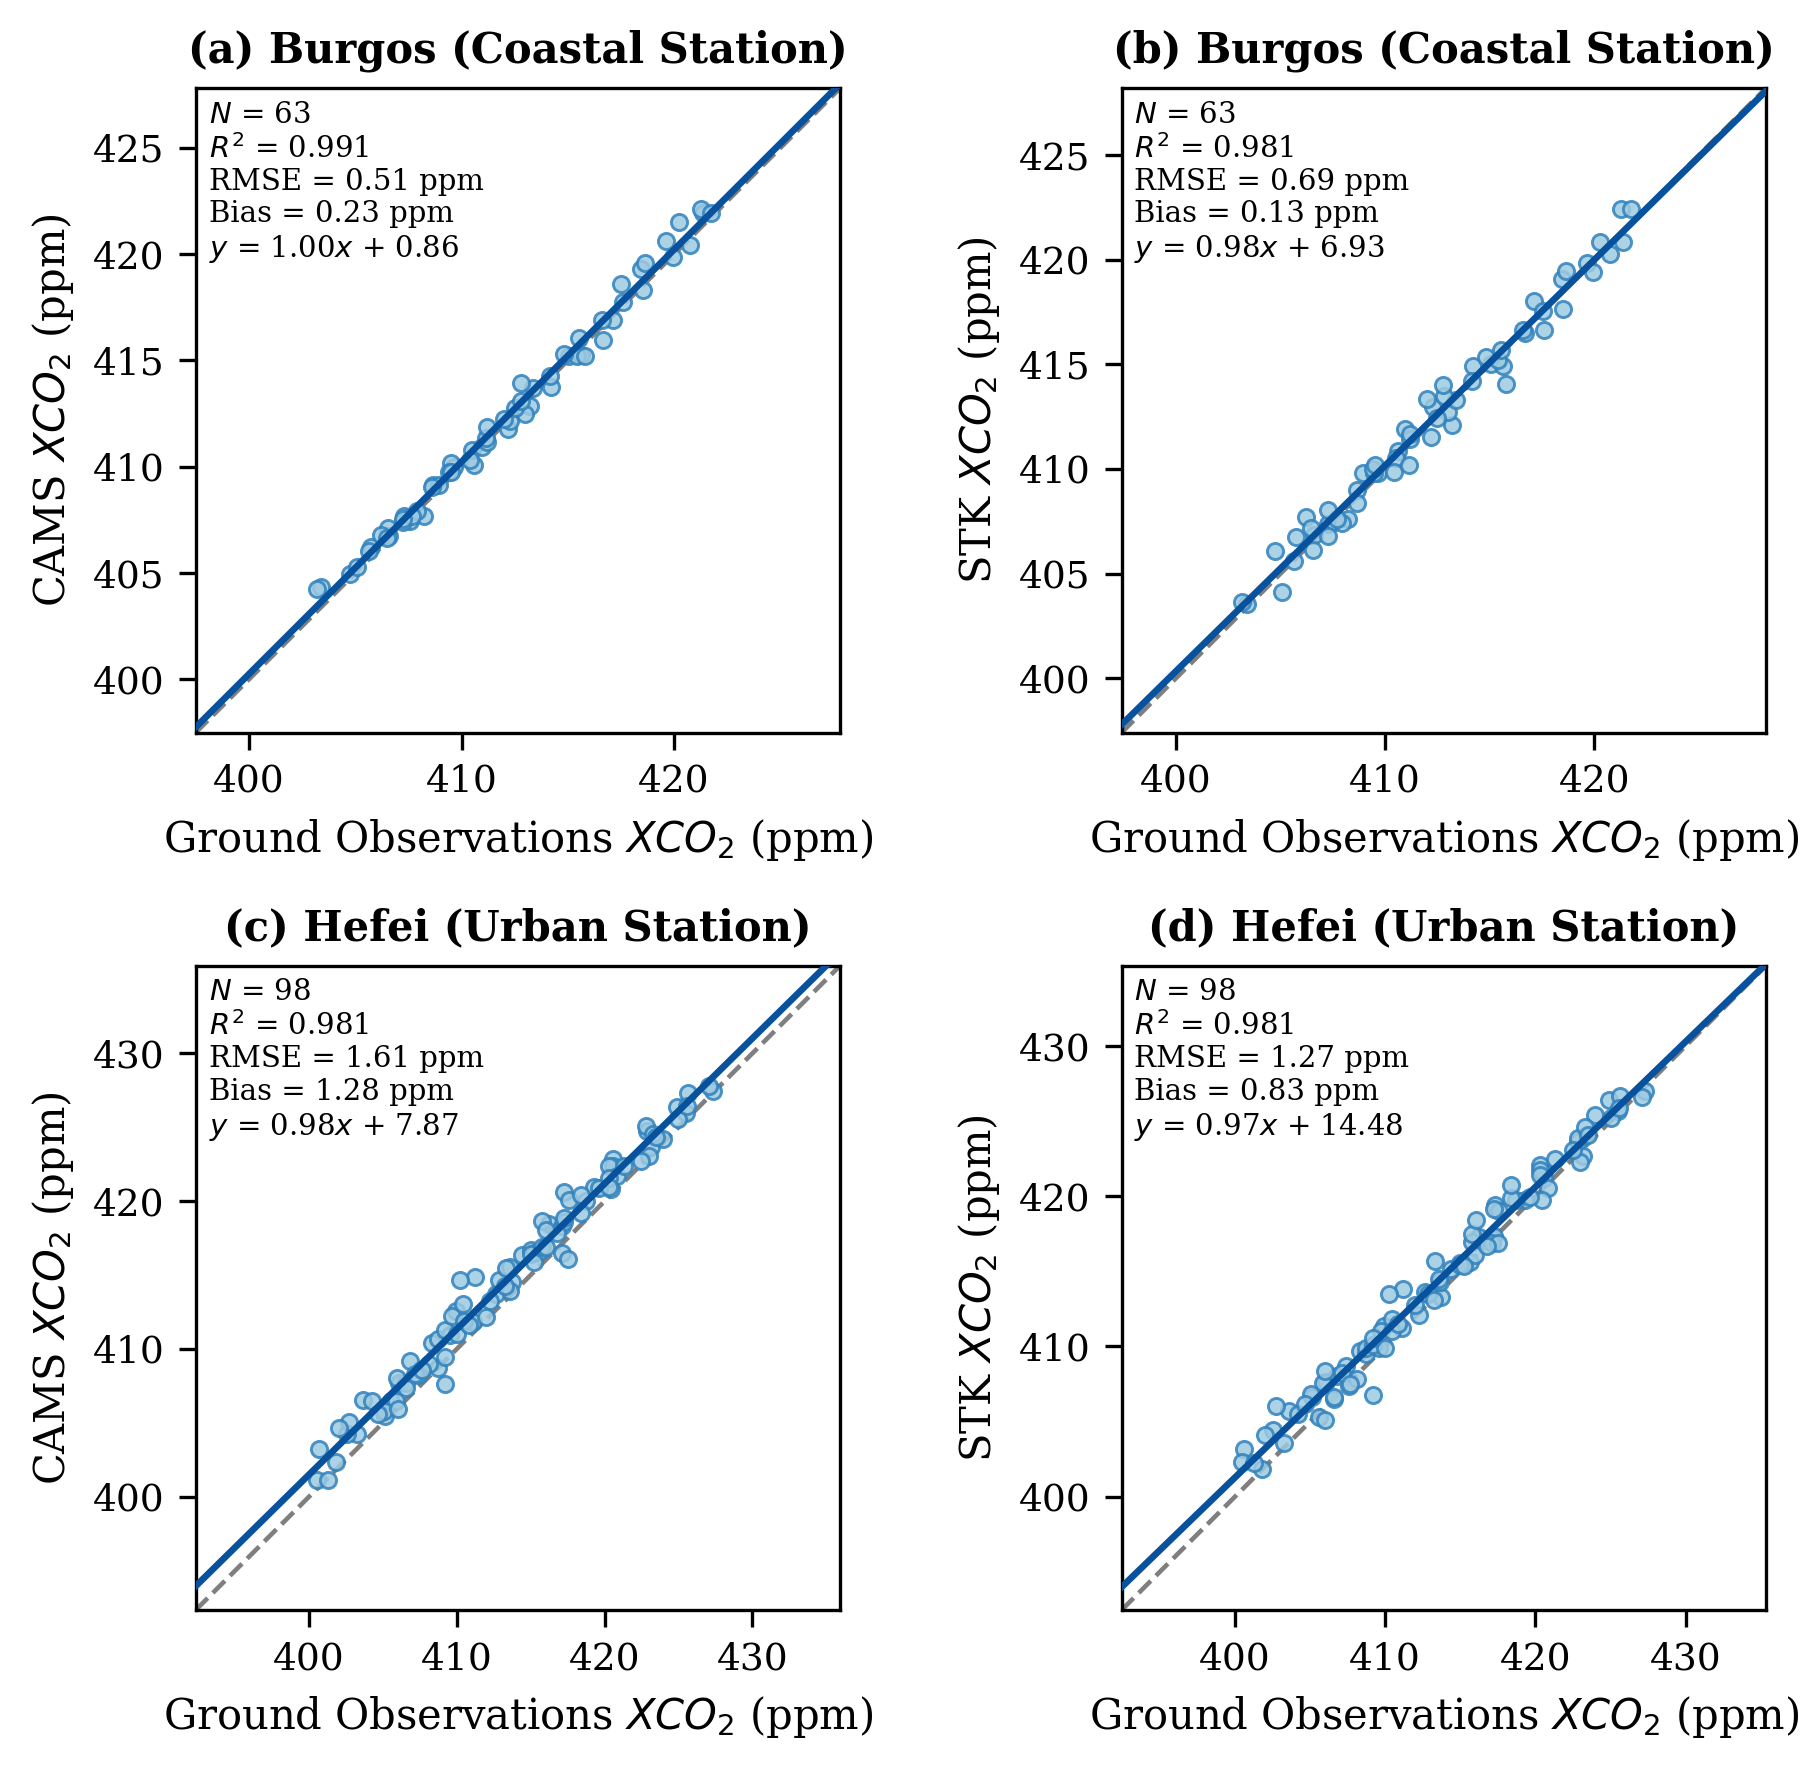

In [ ]:
import math
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

cams_fn = Validation_DIR / "matched_cams_tccon.csv"
stk_fn  = Validation_DIR / "matched_stk_tccon.csv"

df_cams = pd.read_csv(cams_fn)
df_stk  = pd.read_csv(stk_fn)


sites_cams = set(df_cams["site"].dropna().unique())
sites_stk  = set(df_stk["site"].dropna().unique())
common_sites = sorted(sites_cams & sites_stk)

if len(common_sites) == 0:
    raise ValueError("No common sites found between CAMS and STK data, cannot plot pairwise.")

sites_to_plot = common_sites[:2]


n_rows = len(sites_to_plot)
n_cols = 2

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(3.2 * n_cols, 3 * n_rows),
    dpi=300
)

if n_rows == 1:
    axes = [axes]

def find_ground_col(df):
    potential_cols = ["xco2", "co2", "co2_ppm"]
    cols_lower = {c.lower(): c for c in df.columns}
    for col in potential_cols:
        if col in cols_lower:
            return cols_lower[col]
    return None


panel_idx = 0
map_info = [("cams", df_cams), ("stk", df_stk)]

for i, site in enumerate(sites_to_plot):
    for j, (map_name, df_map) in enumerate(map_info):
        ax = axes[i][j] if n_rows > 1 else axes[j]

        sub = df_map[df_map["site"] == site].copy()
        x_col = find_ground_col(sub)

        if sub.empty:
            ax.text(0.5, 0.5, f"No data for\n{site}",
                    ha="center", va="center", fontsize=10)
            ax.set_axis_off()
            panel_idx += 1
            continue

        if x_col is None:
            ax.text(0.5, 0.5, f"No ground XCO$_2$/CO$_2$\ncolumn in {site}",
                    ha="center", va="center", fontsize=10)
            ax.set_axis_off()
            panel_idx += 1
            continue

        display_label = "$XCO_2$" if "xco2" in x_col.lower() else "$CO_2$"

        plot_scatter(
            ax=ax,
            df=sub,
            x_name=x_col,
            y_name=map_name,
            title_name=f"{site} ({SITE_META.get(site, 'Station')})",
            x_label=f"Ground Observations {display_label} (ppm)",
            y_label=f"{map_name.upper()} $XCO_2$ (ppm)",
            sublabel=chr(97 + panel_idx)   # a, b, c, d
        )

        panel_idx += 1


plt.tight_layout()
png_fn = DOC_DIR / "validation_tccon_cams_stk.pdf"
plt.savefig(png_fn, bbox_inches="tight")
print(f"Saved: {png_fn}")
plt.show()

# Temporal Consistency Analysis of CAMS, STK-Reconstructed XCO$_2$, and WDCGG Observations




To evaluate the ability of the CAMS background field and the STK-reconstructed dataset to represent regional background CO$_2$ temporal variability, paired CAMS–WDCGG and STK–WDCGG datasets were read and merged using the `time` and `site` fields. Site-specific time series of WDCGG CO$_2$ observations, CAMS XCO$_2$, and STK-reconstructed XCO$_2$ were then plotted, and the Pearson correlation coefficients ($R$) between CAMS and WDCGG, as well as between STK and WDCGG, were calculated separately. This analysis was primarily intended to assess the consistency of temporal variations captured by different datasets relative to site observations. Since WDCGG reflects near-surface CO$_2$ concentrations, whereas CAMS and STK represent column-averaged dry-air mole fractions of CO$_2$ (XCO$_2$), the two are not directly comparable in terms of observation level and physical meaning. Therefore, this comparison focuses on temporal consistency rather than one-to-one agreement in absolute concentration values.

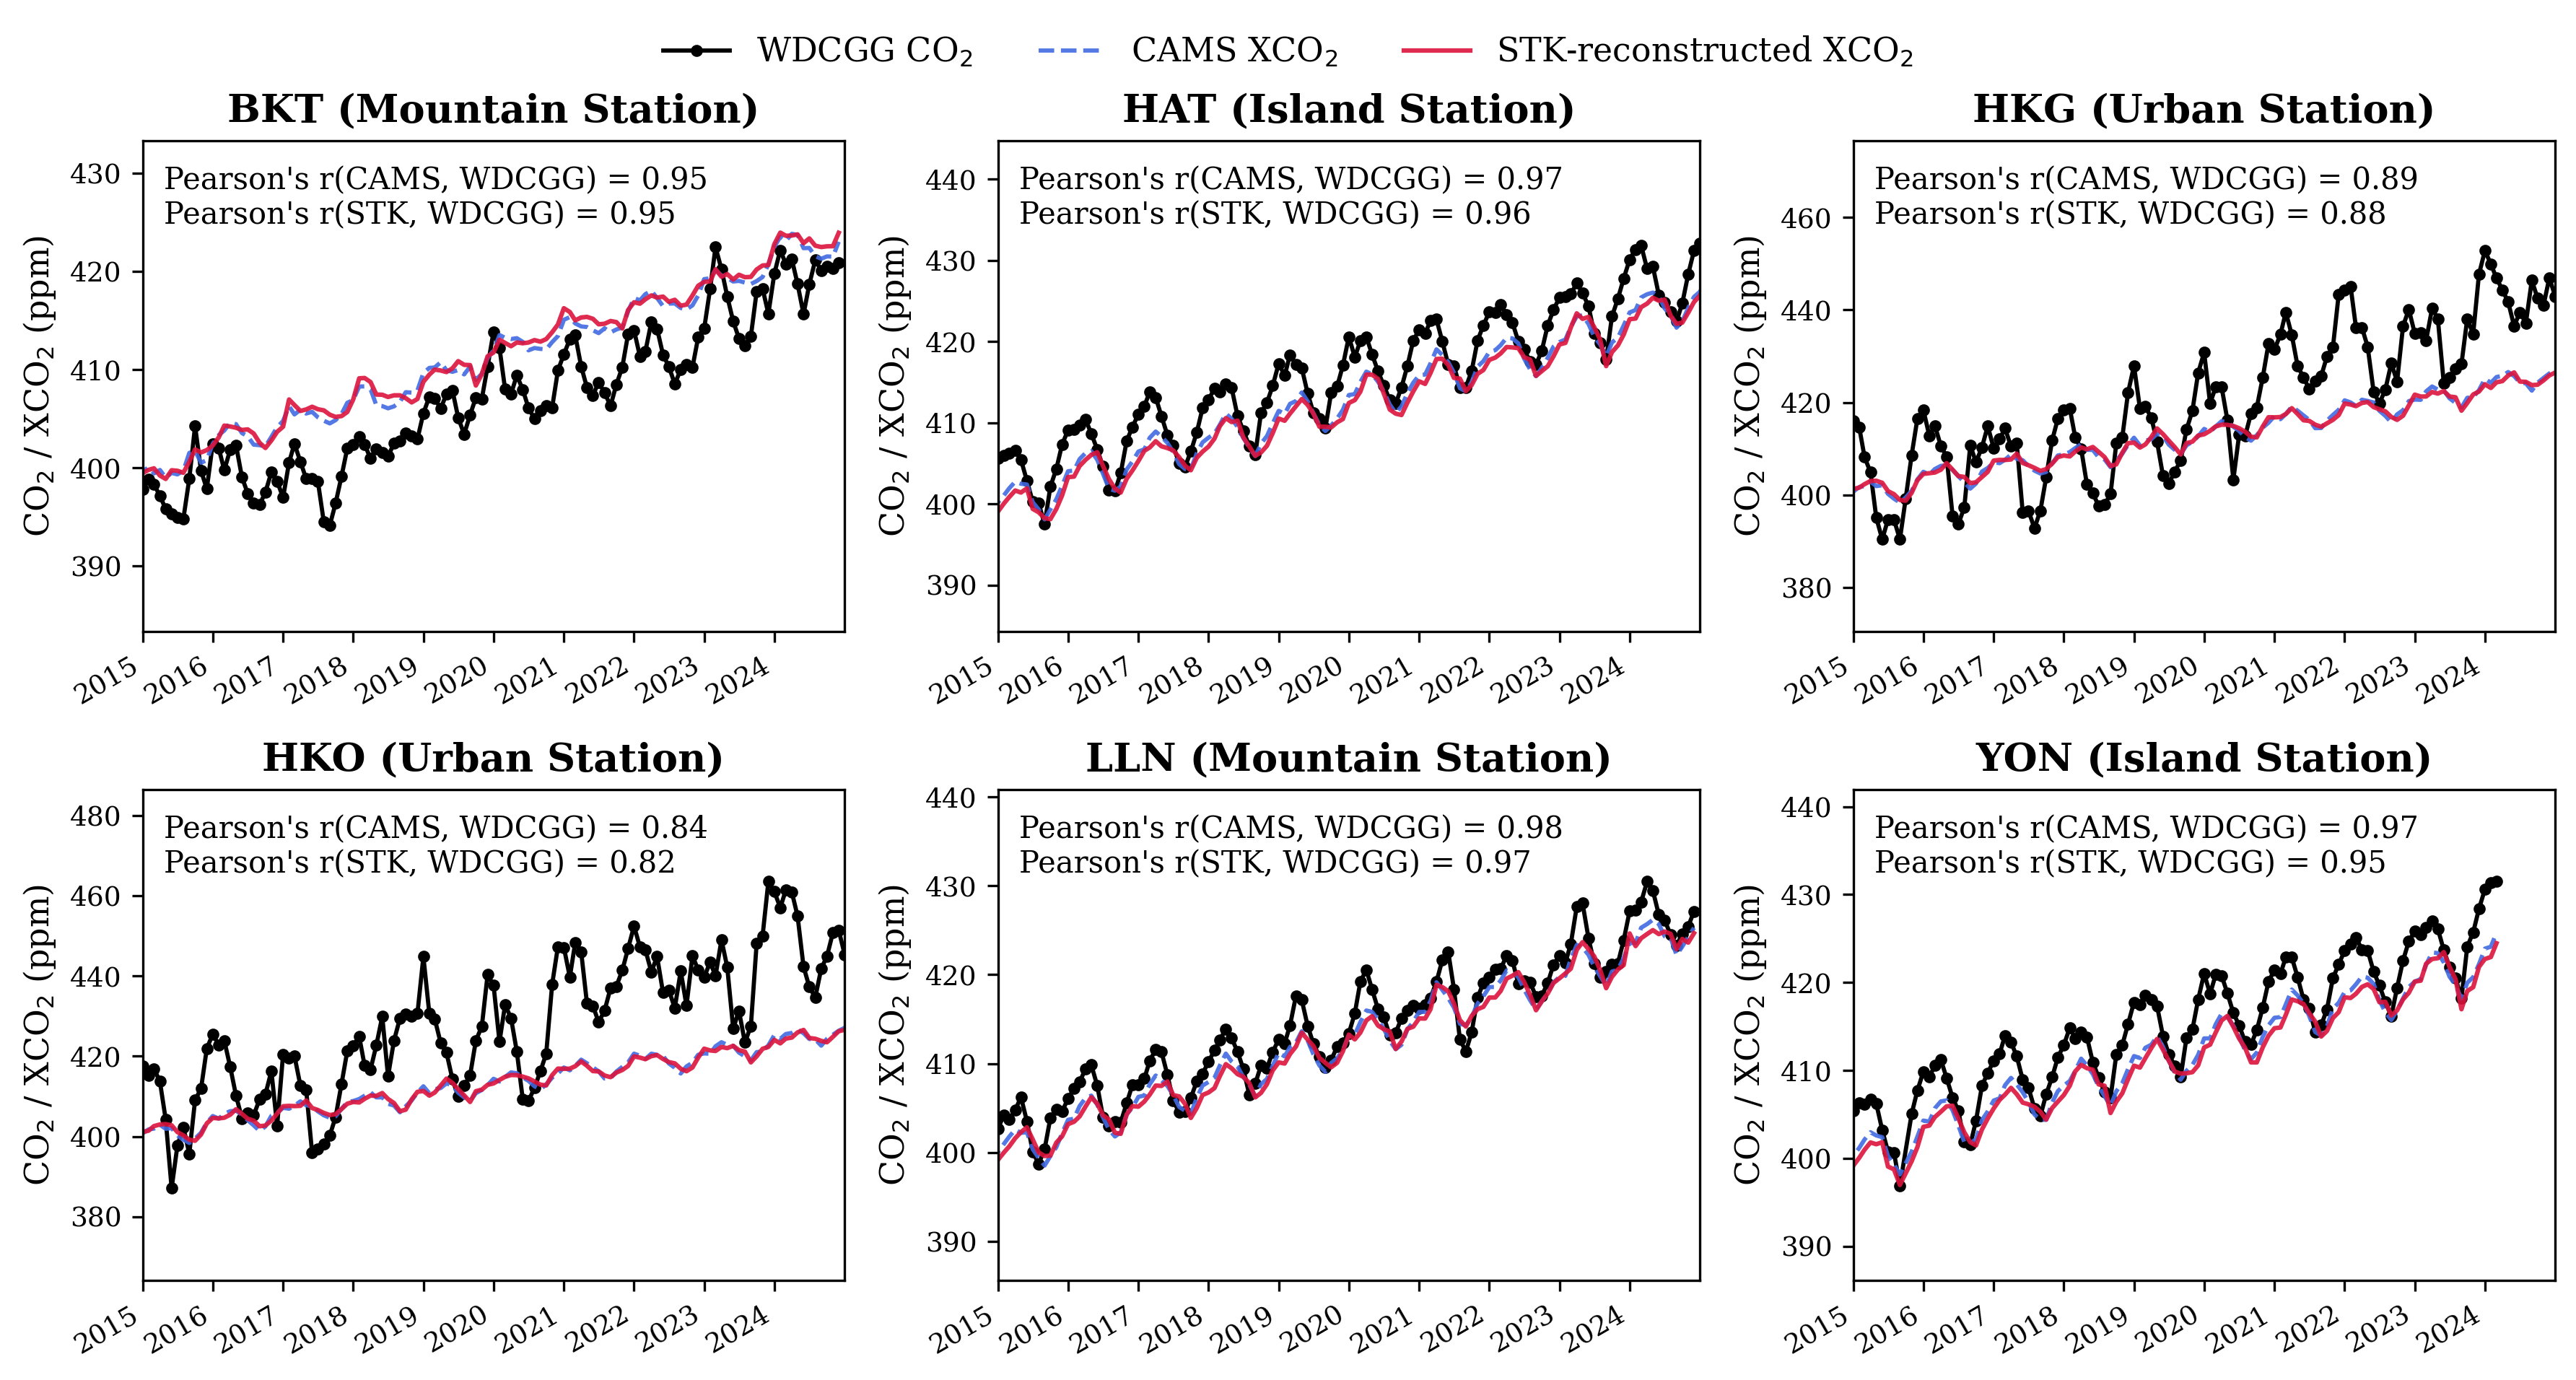

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import math

# =========================
# 1. Read data
# =========================
cams_df = pd.read_csv(Validation_DIR / "matched_cams_wdcgg.csv")
stk_df = pd.read_csv(Validation_DIR / "matched_stk_wdcgg.csv")

cams_df["time"] = pd.to_datetime(cams_df["time"])
stk_df["time"] = pd.to_datetime(stk_df["time"])

# =========================
# 2. Merge data
# =========================
comparison_df = pd.merge(
    cams_df,
    stk_df,
    on=["time", "site"],
    suffixes=("_cams", "_stk")
)

# Select and rename columns
df = comparison_df[["time", "site", "co2_cams", "cams", "stk"]].copy()
df.columns = ["time", "site", "co2", "cams", "stk"]

sites = sorted(df["site"].unique())
n_sites = len(sites)

# =========================
# 3. Figure layout
# =========================
n_cols = 3
n_rows = math.ceil(n_sites / n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(4*n_cols, 3.2 * n_rows),
    sharex=False,
    sharey=False,
    dpi=300
)

if n_sites == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# =========================
# 4. Plot each site
# =========================
### 新增：定义固定的起止时间 ###
start_time = pd.to_datetime("2015-01-01")
end_time = pd.to_datetime("2024-12-31")

for i, site in enumerate(sites):
    ax = axes[i]
    site_data = df[df["site"] == site].sort_values("time").copy()

    if site_data.empty:
        ax.axis("off")
        continue

    # Drop NaNs separately for correlation calculation
    valid_cams = site_data[["co2", "cams"]].dropna()
    valid_stk  = site_data[["co2", "stk"]].dropna()

    r_cams = valid_cams["co2"].corr(valid_cams["cams"]) if len(valid_cams) > 1 else float("nan")
    r_stk  = valid_stk["co2"].corr(valid_stk["stk"]) if len(valid_stk) > 1 else float("nan")

    # Plot lines
    ax.plot(
        site_data["time"], site_data["co2"],
        label="WDCGG CO$_2$",
        color="black",
        linewidth=1.4,
        marker="o",
        markersize=3
    )

    ax.plot(
        site_data["time"], site_data["cams"],
        label="CAMS XCO$_2$",
        color="royalblue",
        linewidth=1.4,
        linestyle="--",
        alpha=0.9
    )

    ax.plot(
        site_data["time"], site_data["stk"],
        label="STK-reconstructed XCO$_2$",
        color="crimson",
        linewidth=1.5,
        linestyle="-",
        alpha=0.9
    )

    # Title and labels
    clean_site = re.sub(r'\d+', '', str(site)).strip()
    # 假设 SITE_META 在你的全局变量中
    info = SITE_META.get(clean_site) if 'SITE_META' in globals() else None
    if info:
        title_text = f"{clean_site} ({info})"
    else:
        title_text = clean_site
    ax.set_title(title_text, fontsize=13, fontweight="bold")
    ax.set_ylabel("CO$_2$ / XCO$_2$ (ppm)", fontsize=11)

    # Grid (原代码注释了这里，你可以按需开启 ax.grid(True))

    # Time axis
    ax.xaxis.set_major_locator(mdates.YearLocator(1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)
    plt.setp(ax.get_yticklabels(), fontsize=9)

    ### 修改 1: 设定时间轴范围 (2015年1月至2024年12月) ###
    ax.set_xlim(start_time, end_time)

    ### 修改 2: 增加 Y 轴留白 ###
    # margins(y=0.3) 表示在数据最大最小值的基础上，上下各增加 30% 的空白空间
    ax.margins(y=0.3)

    # Annotation of correlation coefficients# Annotation of correlation coefficients
    ax.text(
        0.03, 0.95,
        f"Pearson's r(CAMS, WDCGG) = {r_cams:.2f}\nPearson's r(STK, WDCGG) = {r_stk:.2f}",
        transform=ax.transAxes,
        fontsize=10,
        va="top",
        ha="left",
        # edgecolor='none' 去除边框，facecolor='none' 去除白底使之完全透明
        bbox=dict(boxstyle="round,pad=0.3", facecolor="none", edgecolor="none")
    )

# =========================
# 5. Hide unused subplots
# =========================
for j in range(n_sites, len(axes)):
    axes[j].axis("off")

# =========================
# 6. Shared legend
# =========================
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    ncol=3,
    frameon=False,           # 关闭边框
    edgecolor='none',        # 强制边框颜色为无
    facecolor='none',        # 强制背景透明
    fontsize=11,
    bbox_to_anchor=(0.5, 1.0)
)

# =========================
# 7. Layout
# =========================
fig.tight_layout(rect=[0, 0, 1, 0.96])
png_fn = DOC_DIR / "validation_wdgcc_cams_stk.pdf"
plt.savefig(png_fn, bbox_inches='tight')
plt.show()

#Independent cross-validation using processed OCO-3 monthly XCO2 data

OCO-3 monthly XCO2 data, processed using the same quality control, gridding, monthly adjustment procedures as OCO-2, were used as an independent
dataset for cross-validation of the reconstructed XCO2 product.

stk (Matching reconstructed data with OCO-3): Saved as matched_stk_oco3.csv
cams (Matching cams data with OCO-3): Saved as matched_cams_oco3.csv
daily (Matching gridded daily OCO-2 and OCO-3): Saved as matched_oco2_oco3_daily.csv

month (Matching monthly OCO-2 and OCO-3 processed via the Keeling curve): Saved as matched_oco2_oco3_month.csv

In [3]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from scipy.stats import gaussian_kde
from sklearn.metrics import mean_squared_error

for match_name in ["daily", "month", "stk","cams"]:
    if match_name == "stk":
        ref_path = PROJECT_DIR / "data/Satellite/step03_Keeling_curve/oco3_xco2_month_201908_202512.nc"
        test_path = PROJECT_DIR / "output/oco2_xco2_month_2015_2024_stk_SEA.nc"
        matched_csv = Validation_DIR / f"matched_stk_oco3.csv"
        ref_name = "oco3"
        test_name="stk"
    elif match_name == "daily":
        ref_path = PROJECT_DIR / "data/Satellite/step02_grid/oco2_xco2_daily_201409_202512.nc"
        test_path = PROJECT_DIR / "data/Satellite/step02_grid/oco3_xco2_daily_201908_202512.nc"
        matched_csv = Validation_DIR / f"matched_oco2_oco3_daily.csv"
        ref_name = "oco2"
        test_name="oco3"
    elif match_name == "month":
        ref_path = PROJECT_DIR / "data/Satellite/step03_Keeling_curve/oco2_xco2_month_201409_202512.nc"
        test_path = PROJECT_DIR / "data/Satellite/step03_Keeling_curve/oco3_xco2_month_201908_202512.nc"
        matched_csv = Validation_DIR / f"matched_oco2_oco3_month.csv"
        ref_name = "oco2"
        test_name="oco3"
    elif match_name == "cams":
        ref_path = PROJECT_DIR / "data/cams/cams_xco2_month_2015_2024_resize.nc"
        test_path = PROJECT_DIR / "data/Satellite/step03_Keeling_curve/oco3_xco2_month_201908_202512.nc"
        matched_csv = Validation_DIR / f"matched_cams_oco3_month.csv"
        ref_name = "cams"
        test_name="oco3"

    ds_ref = xr.open_dataset(ref_path)
    ds_test = xr.open_dataset(test_path)

    if 'time' in ds_ref.dims:
        ds_ref = ds_ref.drop_duplicates(dim='time')
    if 'time' in ds_test.dims:
        ds_test = ds_test.drop_duplicates(dim='time')

    start_time = max(ds_ref.time.min(), ds_test.time.min())
    end_time = min(ds_ref.time.max(), ds_test.time.max())
    time_slice = slice(start_time, end_time)

    EXTENT = [92, 143, -10, 32]
    lon_slice = slice(EXTENT[0], EXTENT[1])
    lat_slice = slice(EXTENT[2], EXTENT[3])

    ds_ref_roi = ds_ref.sel(time=time_slice, lat=lat_slice, lon=lon_slice)
    ds_test_roi = ds_test.sel(time=time_slice, lat=lat_slice, lon=lon_slice)

    ds_test_aligned = ds_test_roi.reindex_like(ds_ref_roi, method="nearest")

    print(f"\n--- Processing: {match_name}match:{ref_name}---{ref_name}")
    print(f"Aligned time range: {start_time.values} to {end_time.values}")
    print(f"Validation set shape: {ds_ref_roi.dims}")
    print(f"Test set shape: {ds_test_aligned.dims}")

    var_name = 'xco2'
    ref_vals = ds_ref_roi[var_name].values
    test_vals = ds_test_aligned[var_name].values

    valid_mask = ~np.isnan(ref_vals) & ~np.isnan(test_vals)

    ref_clean = ref_vals[valid_mask]
    test_clean = test_vals[valid_mask]

    df_clean = pd.DataFrame({
        ref_name: ref_clean,
        test_name: test_clean
    })

    df_clean.to_csv(matched_csv, index=False)
    print(f"Saved: {matched_csv}")


--- Processing: dailymatch:oco2---oco2
Aligned time range: 2019-08-06T00:00:00.000000000 to 2025-12-29T00:00:00.000000000
Validation set shape: FrozenMappingWarningOnValuesAccess({'time': 2266, 'lat': 420, 'lon': 510})
Test set shape: FrozenMappingWarningOnValuesAccess({'time': 2266, 'lat': 420, 'lon': 510})
Saved: /content/drive/MyDrive/Southeast-Asia-XCO2-STK/output/Validation/matched_oco2_oco3_daily.csv

--- Processing: monthmatch:oco2---oco2
Aligned time range: 2019-08-01T00:00:00.000000000 to 2025-12-01T00:00:00.000000000
Validation set shape: FrozenMappingWarningOnValuesAccess({'time': 77, 'lat': 420, 'lon': 510})
Test set shape: FrozenMappingWarningOnValuesAccess({'time': 77, 'lat': 420, 'lon': 510})
Saved: /content/drive/MyDrive/Southeast-Asia-XCO2-STK/output/Validation/matched_oco2_oco3_month.csv

--- Processing: stkmatch:oco3---oco3
Aligned time range: 2019-08-01T00:00:00.000000000 to 2025-07-01T00:00:00.000000000
Validation set shape: FrozenMappingWarningOnValuesAccess({'ti

Number of data points involved in plotting: 2316
Number of data points involved in plotting: 80110
Number of data points involved in plotting: 100000
Number of data points involved in plotting: 100000
Saved: /content/drive/MyDrive/Southeast-Asia-XCO2-STK/docs/validation_oco3_stk.png


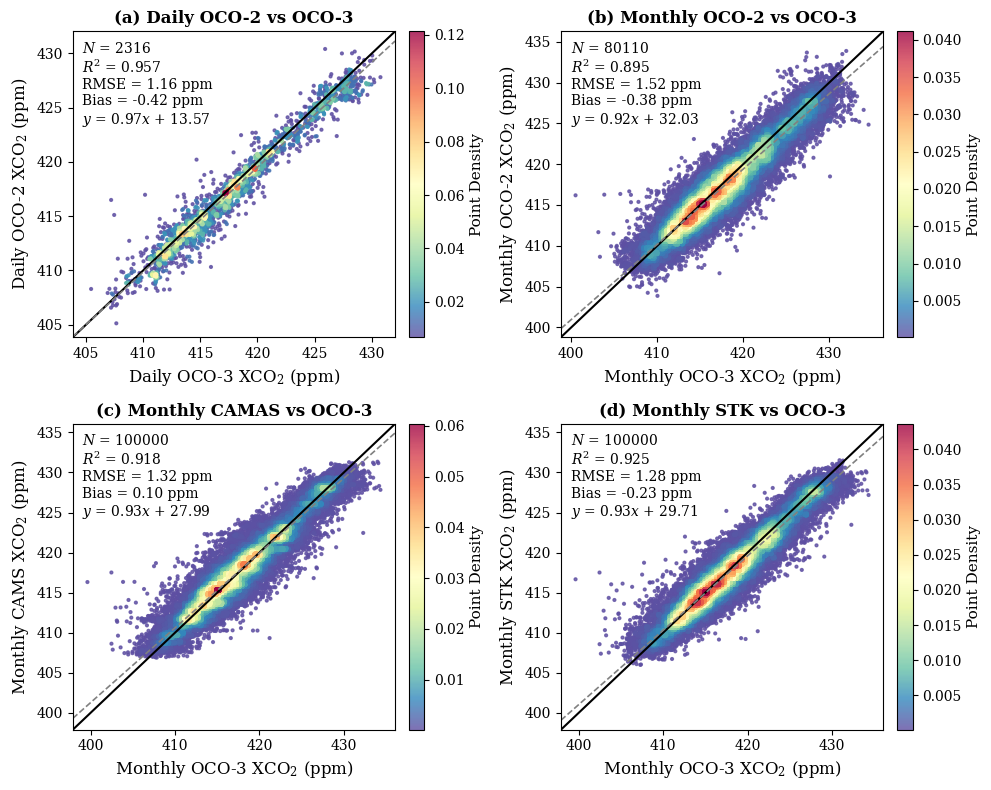

In [ ]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import mean_squared_error

# --- 1. Global Style Adjustments ---
# Set the font family to match the serif style in the provided image
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

# --- 2. Custom Plotting Function ---
def plot_density_scatter(ax, df, x_name, y_name, title_name, x_label, y_label, sublabel, fontsize=12):
    # Extract data and drop NaNs
    df_clean = df.dropna(subset=[x_name, y_name])
    x = df_clean[x_name].values
    y = df_clean[y_name].values

    # Calculate Point Density (using 2D histogram for fast processing of 100k points)
    bins = 100
    H, xedges, yedges = np.histogram2d(x, y, bins=bins, density=True)
    x_idx = np.clip(np.digitize(x, xedges) - 1, 0, bins - 1)
    y_idx = np.clip(np.digitize(y, yedges) - 1, 0, bins - 1)
    density = H[x_idx, y_idx]

    # Sort points by density so the densest points are plotted on top
    sort_idx = np.argsort(density)
    x_sorted, y_sorted, density_sorted = x[sort_idx], y[sort_idx], density[sort_idx]

    # Scatter plot (Spectral_r matches the colormap in the reference image)
    sc = ax.scatter(x_sorted, y_sorted, c=density_sorted, cmap='Spectral_r', s=4, alpha=0.8)

    # Calculate Metrics
    N = len(x)
    slope, intercept, r_value, _, _ = stats.linregress(x, y)
    r2 = r_value**2
    rmse = np.sqrt(mean_squared_error(x, y))
    bias = np.mean(y - x)

    # Determine axis limits for a perfectly square 1:1 plot
    min_val = min(np.min(x), np.min(y))
    max_val = max(np.max(x), np.max(y))
    pad = (max_val - min_val) * 0.05
    lims = [min_val - pad, max_val + pad]
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    # Draw 1:1 Line (Solid Black)
    ax.plot(lims, lims, color='black', linestyle='-', linewidth=1.5)

    # Draw Regression Line (Dashed Gray)
    x_fit = np.array(lims)
    y_fit = slope * x_fit + intercept
    ax.plot(x_fit, y_fit, color='gray', linestyle='--', linewidth=1.2)

    # Add Text Box for Statistics
    text_str = (f"$N$ = {N}\n"
                f"$R^2$ = {r2:.3f}\n"
                f"RMSE = {rmse:.2f} ppm\n"
                f"Bias = {bias:.2f} ppm\n"
                f"$y$ = {slope:.2f}$x$ + {intercept:.2f}")

    ax.text(0.03, 0.97, text_str, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(facecolor='none', edgecolor='none'))

    # Labels and Bold Title formatting: (a) Title Name
    ax.set_xlabel(x_label, fontsize=fontsize)
    ax.set_ylabel(y_label, fontsize=fontsize)
    ax.set_title(f"({sublabel}) {title_name}", fontsize=fontsize, fontweight='bold')

    return sc, True

# --- 3. Main Execution Loop ---
fig, axes = plt.subplots(2, 2, figsize=(10, 8)) # Adjusted width/height for better proportions

for i, match_name in enumerate(["daily", "month", "cams", "stk"]):
    if match_name == "stk":
        matched_csv = Validation_DIR / f"matched_stk_oco3.csv"
        ref_name = "stk"
        test_name="oco3"
        x_label='Monthly OCO-3 XCO$_2$ (ppm)'
        y_label='Monthly STK XCO$_2$ (ppm)'
        title_name="Monthly STK vs OCO-3"
    elif match_name == "daily":
        matched_csv = Validation_DIR / f"matched_oco2_oco3_daily.csv"
        ref_name = "oco2"
        test_name="oco3"
        x_label='Daily OCO-3 XCO$_2$ (ppm)'
        y_label='Daily OCO-2 XCO$_2$ (ppm)'
        title_name="Daily OCO-2 vs OCO-3"
    elif match_name == "month":
        matched_csv = Validation_DIR / f"matched_oco2_oco3_month.csv"
        ref_name = "oco2"
        test_name="oco3"
        x_label='Monthly OCO-3 XCO$_2$ (ppm)'
        y_label='Monthly OCO-2 XCO$_2$ (ppm)'
        title_name="Monthly OCO-2 vs OCO-3"
    elif match_name == "cams":
        matched_csv = Validation_DIR / f"matched_cams_oco3_month.csv"
        ref_name = "cams"
        test_name="oco3"
        x_label='Monthly OCO-3 XCO$_2$ (ppm)'
        y_label='Monthly CAMS XCO$_2$ (ppm)'
        title_name="Monthly CAMAS vs OCO-3"

    df = pd.read_csv(matched_csv)
    sample_size = 100000
    if len(df) > sample_size:
        df_sampled = df.sample(n=sample_size, random_state=42)
    else:
        df_sampled = df

    print(f"Number of data points involved in plotting: {len(df_sampled)}")

    row_idx = i // 2
    col_idx = i % 2
    ax = axes[row_idx, col_idx]

    sc, use_density = plot_density_scatter(
        ax=ax,
        df=df_sampled,
        x_name=test_name,  # Corrected: test_name (OCO-3) is mapped to the X-axis
        y_name=ref_name,   # Corrected: ref_name is mapped to the Y-axis
        title_name=title_name,
        x_label=x_label,
        y_label=y_label,
        sublabel=chr(97+i),
        fontsize=12
    )

    if use_density and sc is not None:
        cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Point Density', fontsize=11)

plt.tight_layout()
png_fn = DOC_DIR / "validation_oco3_stk.pdf"
plt.savefig(png_fn, bbox_inches="tight", dpi=300)
png_fn = DOC_DIR / "validation_oco3_stk.png"
plt.savefig(png_fn, bbox_inches="tight", dpi=300)
print(f"Saved: {png_fn}")
plt.show()

# 误差的时间分布

Validation period: 2019-08 – 2024-12

Monthly statistics:
 Month     N  CAMS_RMSE  STK_RMSE  CAMS_Bias  STK_Bias  Improvement_%
     1 32329      1.722     1.527      0.320    -0.127         11.327
     2 33290      1.514     1.478     -0.178    -0.452          2.406
     3 32773      1.430     1.391      0.270    -0.239          2.793
     4 37090      1.436     1.419      0.376    -0.311          1.200
     5 28488      1.277     1.305      0.145    -0.173         -2.229
     6 25202      1.351     1.343     -0.206    -0.291          0.541
     7 20339      1.613     1.552     -0.742    -0.650          3.793
     8 29660      1.501     1.521     -0.255    -0.182         -1.346
     9 29599      1.604     1.575     -0.449    -0.368          1.810
    10 33950      1.636     1.539      0.287    -0.110          5.937
    11 31032      1.693     1.502      0.422    -0.018         11.278
    12 38049      1.577     1.455      0.121    -0.292          7.739

STK lower RMSE: 10/12 months
Mo

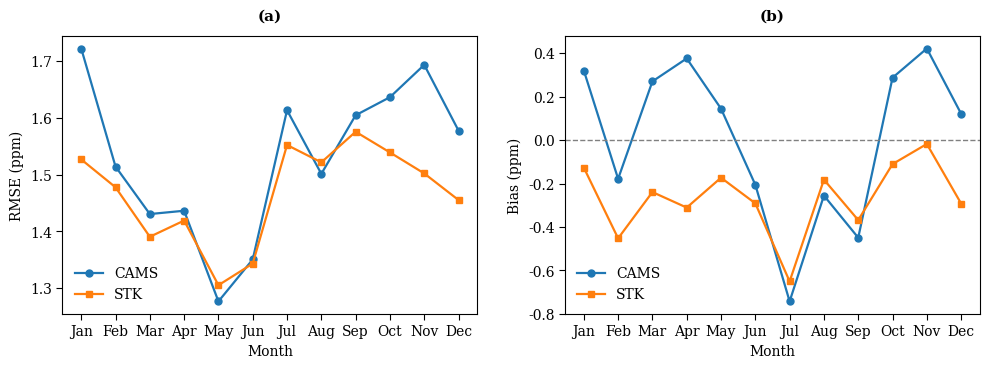

In [4]:
# ============================================================
# Figure 7. Monthly RMSE and Bias: CAMS vs STK against OCO-3
# Bias = Product - OCO-3
# ============================================================

PROJECT_DIR = Path("/content/drive/MyDrive/Southeast-Asia-XCO2-STK")

oco3_nc = PROJECT_DIR / "data/Satellite/step03_Keeling_curve/oco3_xco2_month_201908_202512.nc"
stk_nc  = PROJECT_DIR / "output/oco2_xco2_month_2015_2024_stk_SEA.nc"
cams_nc = PROJECT_DIR / "data/cams/cams_xco2_month_2015_2024_resize.nc"
oco3_nc = PROJECT_DIR / "data/Satellite/step03_Keeling_curve/oco3_xco2_month_201908_202512.nc"

# ------------------------------------------------------------
# 1. Read and preprocess
# ------------------------------------------------------------
def read_monthly(path):
    ds = xr.open_dataset(path)

    # 统一为月初时间
    time = pd.to_datetime(ds.time.values).to_period("M").to_timestamp()
    ds = ds.assign_coords(time=time).drop_duplicates("time").sortby("time")

    # 自动判断纬度方向
    lat_slice = slice(-10, 32) if ds.lat[0] < ds.lat[-1] else slice(32, -10)

    return ds["xco2"].sel(
        time=slice("2019-08-01", "2024-12-31"),
        lon=slice(92, 125),
        lat=lat_slice
    )


oco3 = read_monthly(oco3_nc)
stk  = read_monthly(stk_nc)
cams = read_monthly(cams_nc)


# ------------------------------------------------------------
# 2. Common time
# ------------------------------------------------------------
common_time = np.intersect1d(oco3.time.values, stk.time.values)
common_time = np.intersect1d(common_time, cams.time.values)

oco3 = oco3.sel(time=common_time)
stk  = stk.sel(time=common_time)
cams = cams.sel(time=common_time)

print(
    f"Validation period: "
    f"{pd.Timestamp(common_time[0]):%Y-%m} – "
    f"{pd.Timestamp(common_time[-1]):%Y-%m}"
)


# ------------------------------------------------------------
# 3. Match to OCO-3 grid
# ------------------------------------------------------------
stk = stk.interp(
    lat=oco3.lat,
    lon=oco3.lon,
    method="nearest"
)

cams = cams.interp(
    lat=oco3.lat,
    lon=oco3.lon,
    method="nearest"
)


# ------------------------------------------------------------
# 4. Same validation samples
# ------------------------------------------------------------
valid = (
    np.isfinite(oco3) &
    np.isfinite(stk) &
    np.isfinite(cams)
)

# Bias = Product - OCO-3
err_stk  = (stk - oco3).where(valid)
err_cams = (cams - oco3).where(valid)

dims = ("time", "lat", "lon")


# ------------------------------------------------------------
# 5. Monthly RMSE and Bias
# ------------------------------------------------------------
stk_rmse = np.sqrt(
    (err_stk ** 2)
    .groupby("time.month")
    .mean(dims, skipna=True)
)

cams_rmse = np.sqrt(
    (err_cams ** 2)
    .groupby("time.month")
    .mean(dims, skipna=True)
)

stk_bias = (
    err_stk
    .groupby("time.month")
    .mean(dims, skipna=True)
)

cams_bias = (
    err_cams
    .groupby("time.month")
    .mean(dims, skipna=True)
)

N = (
    valid
    .groupby("time.month")
    .sum(dims)
)


# ------------------------------------------------------------
# 6. Save statistics
# ------------------------------------------------------------
df_fig7 = pd.DataFrame({
    "Month": np.arange(1, 13),
    "N": N.values.astype(int),
    "CAMS_RMSE": cams_rmse.values,
    "STK_RMSE": stk_rmse.values,
    "CAMS_Bias": cams_bias.values,
    "STK_Bias": stk_bias.values
})

df_fig7["Improvement_%"] = (
    (df_fig7["CAMS_RMSE"] - df_fig7["STK_RMSE"])
    / df_fig7["CAMS_RMSE"] * 100
)

print("\nMonthly statistics:")
print(df_fig7.round(3).to_string(index=False))

better = df_fig7["STK_RMSE"] < df_fig7["CAMS_RMSE"]

print(f"\nSTK lower RMSE: {better.sum()}/12 months")
print("Months:", df_fig7.loc[better, "Month"].tolist())

df_fig7.to_csv(
    Validation_DIR / "Figure7_monthly_validation_statistics.csv",
    index=False
)


# ============================================================
# 7. Plot Figure 7
# ============================================================
months = np.arange(1, 13)

labels = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

fig, ax = plt.subplots(
    1, 2,
    figsize=(10, 4)
)


# ------------------------------------------------------------
# (a) RMSE
# ------------------------------------------------------------
ax[0].plot(
    months,
    cams_rmse.values,
    marker="o",
    lw=1.6,
    ms=5,
    label="CAMS"
)

ax[0].plot(
    months,
    stk_rmse.values,
    marker="s",
    lw=1.6,
    ms=5,
    label="STK"
)

ax[0].set_xticks(months)
ax[0].set_xticklabels(labels)

ax[0].set_xlabel("Month")
ax[0].set_ylabel("RMSE (ppm)")

# 子图编号：上方外侧居中
ax[0].text(
    0.5, 1.045,
    "(a)",
    transform=ax[0].transAxes,
    ha="center",
    va="bottom",
    fontsize=11,
    fontweight="bold",
    clip_on=False
)

ax[0].legend(
    frameon=False
)


# ------------------------------------------------------------
# (b) Bias
# ------------------------------------------------------------
ax[1].plot(
    months,
    cams_bias.values,
    marker="o",
    lw=1.6,
    ms=5,
    label="CAMS"
)

ax[1].plot(
    months,
    stk_bias.values,
    marker="s",
    lw=1.6,
    ms=5,
    label="STK"
)

# Bias = 0 reference line
ax[1].axhline(
    0,
    color="gray",
    linestyle="--",
    linewidth=1
)

ax[1].set_xticks(months)
ax[1].set_xticklabels(labels)

ax[1].set_xlabel("Month")
ax[1].set_ylabel("Bias (ppm)")

# 子图编号：上方外侧居中
ax[1].text(
    0.5, 1.045,
    "(b)",
    transform=ax[1].transAxes,
    ha="center",
    va="bottom",
    fontsize=11,
    fontweight="bold",
    clip_on=False
)

ax[1].legend(
    frameon=False
)


# ------------------------------------------------------------
# 8. Style
# 四边框保留、内部无网格
# ------------------------------------------------------------
for a in ax:

    a.grid(False)

    for spine in [
        "top",
        "bottom",
        "left",
        "right"
    ]:
        a.spines[spine].set_visible(True)
        a.spines[spine].set_linewidth(0.8)

    a.tick_params(
        axis="both",
        direction="out",
        length=4,
        width=0.8,
        top=False,
        right=False
    )


# 给(a)(b)顶部预留空间
plt.tight_layout(
    rect=[0, 0, 1, 0.95],
    w_pad=2.2
)


# ------------------------------------------------------------
# 9. Save
# ------------------------------------------------------------
plt.savefig(
    Validation_DIR / "Figure7_monthly_CAMS_STK_validation.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    Validation_DIR / "Figure7_monthly_CAMS_STK_validation.pdf",
    bbox_inches="tight"
)

plt.show()

# 误差空间分布

正在读取 OCO-2 和 OCO-3 卫星数据...
正在对齐时空网格并计算误差...
正在绘制空间分布图...


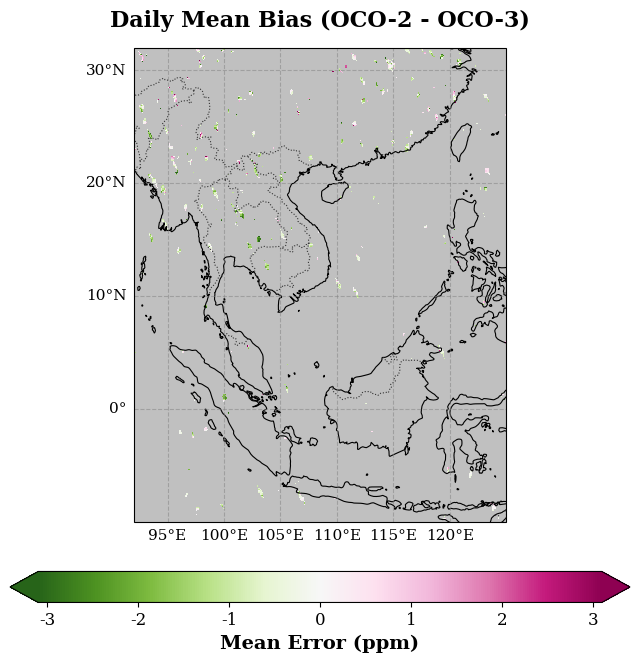

图表绘制完成，已保存至: Figure_Spatial_Daily_Error_OCO2_vs_OCO3.png


In [25]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt  # 只需要这一个 pyplot 即可
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import copy
from pathlib import Path

# ============================================================
# 1. 定义数据路径
# ============================================================
# 请确保 PROJECT_DIR 已正确定义
# PROJECT_DIR = Path("...")
oco2_nc = PROJECT_DIR / "data/Satellite/step02_grid/oco2_xco2_daily_201409_202512.nc"
oco3_nc = PROJECT_DIR / "data/Satellite/step02_grid/oco3_xco2_daily_201908_202512.nc"

# ============================================================
# 2. 读取与日尺度对齐
# ============================================================
def read_daily(path):
    ds = xr.open_dataset(path)
    # 确保时间为 pd.datetime 格式，并去重排序
    if not np.issubdtype(ds.time.dtype, np.datetime64):
        ds['time'] = pd.to_datetime(ds.time.values)
    ds = ds.drop_duplicates("time").sortby("time")

    # 统一纬度切片方向
    lat_slice = slice(-10, 32) if ds.lat[0] < ds.lat[-1] else slice(32, -10)
    return ds["xco2"].sel(lon=slice(92, 125), lat=lat_slice)

print("正在读取 OCO-2 和 OCO-3 卫星数据...")
oco2 = read_daily(oco2_nc)
oco3 = read_daily(oco3_nc)

print("正在对齐时空网格并计算误差...")
# 寻找共同的日期 (日尺度对齐)
common_time = np.intersect1d(oco2.time.values, oco3.time.values)

oco2_c = oco2.sel(time=common_time)
oco3_c = oco3.sel(time=common_time)

# 将 OCO-2 的网格就近插值到 OCO-3 的网格上
oco2_interp = oco2_c.interp(lat=oco3_c.lat, lon=oco3_c.lon, method="nearest")

# 计算日尺度的重叠有效误差： OCO2 - OCO3
valid = np.isfinite(oco2_interp) & np.isfinite(oco3_c)
err_oco2_oco3 = (oco2_interp - oco3_c).where(valid)

# 对时间维度求平均，得到纯空间二维数据
mean_err = err_oco2_oco3.mean(dim="time", skipna=True)

# ============================================================
# 3. 绘制误差空间分布图 (PiYG 色带 + 灰色背景)
# ============================================================
print("正在绘制空间分布图...")

# 获取有效数据来确定色标范围，确保正负完全对称 (0 = 纯白)
valid_errs = mean_err.values[np.isfinite(mean_err.values)]
vmax = np.percentile(np.abs(valid_errs), 98) if len(valid_errs) > 0 else 2.0
vmin = -vmax

# 设置 PiYG 渐变色，并将无数据(NaN)的地方指定为灰色(silver)
# 加 _r 表示反转(粉红代表正偏差高估，翠绿代表负偏差低估)
cmap = copy.copy(plt.get_cmap('PiYG_r'))
cmap.set_bad('silver')

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# 设置海陆背景底色为灰色
ax.set_facecolor('silver')

# 绘制网格数据
im = ax.pcolormesh(
    oco3_c.lon, oco3_c.lat, mean_err,
    cmap=cmap,
    vmin=vmin, vmax=vmax,
    transform=ccrs.PlateCarree(),
    shading='auto'
)

# 添加图名与地图要素
ax.set_title("Daily Mean Bias (OCO-2 - OCO-3)", fontsize=16, fontweight='bold', pad=15)
ax.set_extent([92, 125, -10, 32], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.8, edgecolor='#333333')

# 添加经纬网格线
gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 11}
gl.ylabel_style = {'size': 11}

# 添加 Colorbar
cbar = plt.colorbar(im, ax=ax, orientation='horizontal', extend='both', shrink=0.8, pad=0.08)
cbar.set_label('Mean Error (ppm)', fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=12)

# 保存图片
save_path = Path("Figure_Spatial_Daily_Error_OCO2_vs_OCO3.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"图表绘制完成，已保存至: {save_path}")

正在计算匹配数据点数量并绘图...


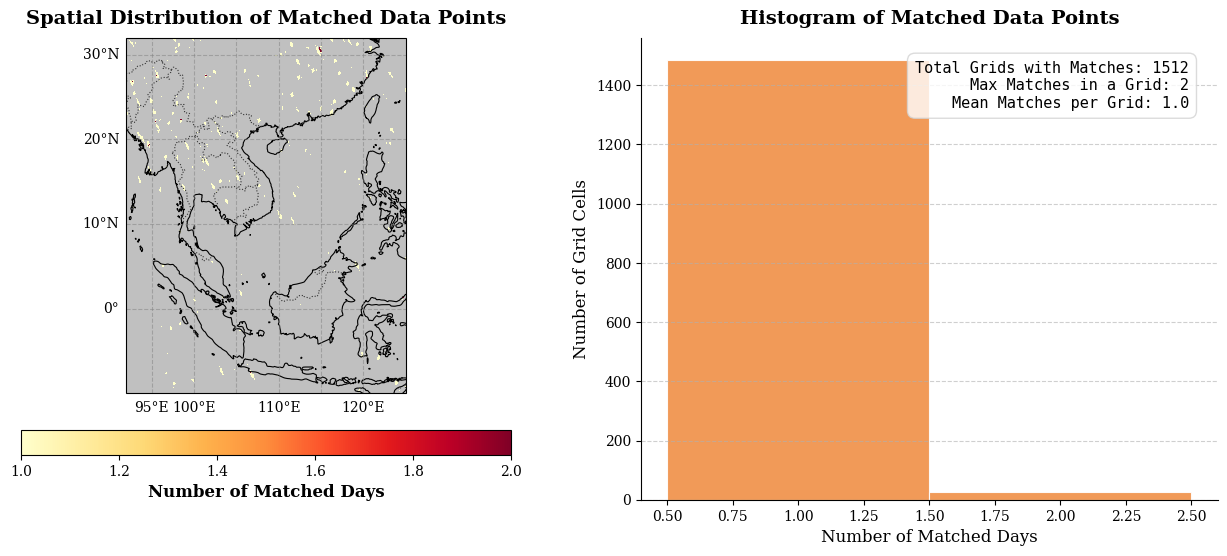

匹配数据点统计图绘制完成，已保存至: Figure_Matched_Data_Points.png


In [26]:
# ============================================================
# 4. 匹配数据点的空间分布与频数直方图
# ============================================================
print("正在计算匹配数据点数量并绘图...")

# 计算每个网格在时间维度上有多少天是同时有 OCO-2 和 OCO-3 数据的
# valid 是上一步代码中计算出的布尔型掩码 (time, lat, lon)
match_count = valid.sum(dim="time")

# 将匹配次数为 0 的网格设为 NaN（为了在地图上显示为银灰色，不在直方图中统计）
match_count_masked = match_count.where(match_count > 0)

# 提取一维有效数据，用于画直方图
count_1d = match_count_masked.values.ravel()
count_1d = count_1d[np.isfinite(count_1d)]

# ------------------------------------------------------------
# 绘图设计：左边画地图，右边画直方图
# ------------------------------------------------------------
fig = plt.figure(figsize=(16, 6))

# ---- (1) 左图：匹配点数量的空间分布 (Map) ----
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax1.set_facecolor('silver') # 无数据区域显示灰色

# 选择一个代表数量级递增的色标，例如 'viridis' 或 'YlOrRd' (黄-橙-红)
cmap_count = copy.copy(plt.get_cmap('YlOrRd'))
cmap_count.set_bad('silver')

im = ax1.pcolormesh(
    oco3_c.lon, oco3_c.lat, match_count_masked,
    cmap=cmap_count,
    transform=ccrs.PlateCarree(),
    shading='auto'
)

ax1.set_title("Spatial Distribution of Matched Data Points", fontsize=14, fontweight='bold', pad=10)
ax1.set_extent([92, 125, -10, 32], crs=ccrs.PlateCarree())
ax1.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')
ax1.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.8, edgecolor='#333333')

gl = ax1.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

cbar = plt.colorbar(im, ax=ax1, orientation='horizontal', shrink=0.85, pad=0.08)
cbar.set_label('Number of Matched Days', fontsize=12, fontweight='bold')


# ---- (2) 右图：匹配点数量的直方图 (Histogram) ----
ax2 = fig.add_subplot(1, 2, 2)

# 如果匹配点数量的最大值不大，可以让 bins 的数量等于最大天数
max_count = int(count_1d.max()) if len(count_1d) > 0 else 10
bins = np.arange(1, max_count + 2) - 0.5 if max_count < 50 else 50

ax2.hist(
    count_1d,
    bins=bins,
    color='#f08f46',
    edgecolor='white',
    linewidth=0.8,
    alpha=0.9
)

ax2.set_title("Histogram of Matched Data Points", fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel("Number of Matched Days", fontsize=12)
ax2.set_ylabel("Number of Grid Cells", fontsize=12)

# 图表装饰
ax2.grid(axis='y', linestyle='--', alpha=0.6)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# 在右上角添加统计文本
stats_text = (
    f"Total Grids with Matches: {len(count_1d)}\n"
    f"Max Matches in a Grid: {max_count}\n"
    f"Mean Matches per Grid: {count_1d.mean():.1f}"
)
ax2.text(0.95, 0.95, stats_text, transform=ax2.transAxes, va='top', ha='right',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='lightgray', boxstyle='round,pad=0.5'),
         fontsize=11, family='monospace')

plt.subplots_adjust(wspace=0.15)

# 保存图片
save_path_count = Path("Figure_Matched_Data_Points.png")
plt.savefig(save_path_count, dpi=300, bbox_inches='tight')
plt.show()

print(f"匹配数据点统计图绘制完成，已保存至: {save_path_count}")


正在生成各区间的散点密度图...


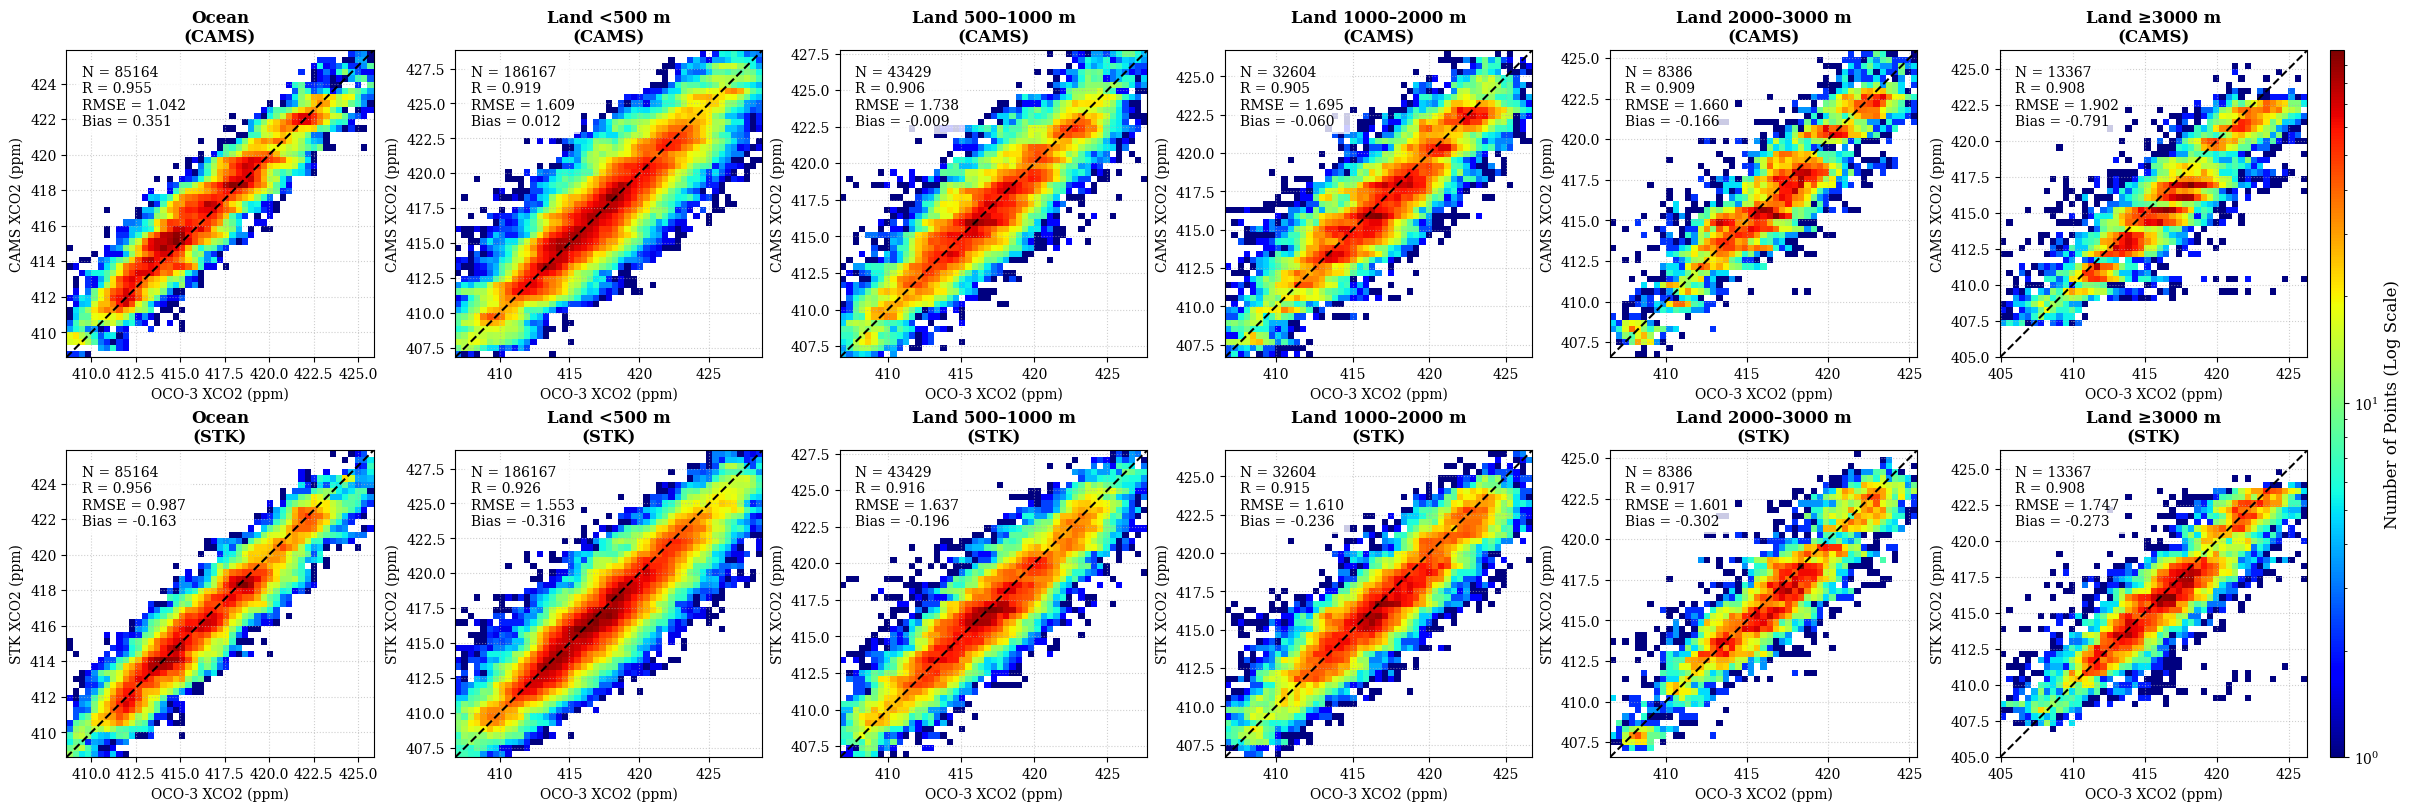

绘图完成，图片已保存至: Figure_Elevation_ScatterDensity.png


In [15]:
import matplotlib.colors as mcolors
from scipy.stats import pearsonr

# ============================================================
# 4. Scatter Density Plots by Elevation Class
# ============================================================
print("\n正在生成各区间的散点密度图...")

# 设置画布大小：2行 (CAMS, STK) x 6列 (各个分类)
fig, axes = plt.subplots(nrows=2, ncols=len(classes), figsize=(24, 8), constrained_layout=True)

# 统一全局颜色条的最大值和最小值，方便对比（可选）
cmap = plt.cm.jet  # 你也可以换成 'viridis' 或 'Spectral_r'

for i, (name, mask) in enumerate(classes.items()):
    # 将 mask 转换为和卫星数据一样的格式
    m = xr.DataArray(
        mask,
        coords={"lat": oco3.lat, "lon": oco3.lon},
        dims=("lat", "lon")
    )

    # 提取真实值用于画图 (X轴: OCO3, Y轴: 模型)
    o_vals = oco3.where(m).values.ravel()
    c_vals = cams.where(m).values.ravel()
    s_vals = stk.where(m).values.ravel()

    # 过滤 NaN 值
    valid_idx = np.isfinite(o_vals) & np.isfinite(c_vals) & np.isfinite(s_vals)
    o, c, s = o_vals[valid_idx], c_vals[valid_idx], s_vals[valid_idx]

    ax_c = axes[0, i]  # 第一行：CAMS
    ax_s = axes[1, i]  # 第二行：STK

    if len(o) < 10:
        ax_c.set_title(f"{name}\nNo Data")
        ax_c.axis('off')
        ax_s.axis('off')
        continue

    # 计算当前子图的坐标轴范围 (取数据的 0.1% ~ 99.9% 分位数，避免极端异常值拉偏坐标轴)
    vmin = np.percentile(np.concatenate([o, c, s]), 0.1)
    vmax = np.percentile(np.concatenate([o, c, s]), 99.9)
    bins = np.linspace(vmin, vmax, 50) # 划分 50x50 个网格

    # ------ (1) 绘制 CAMS 散点密度图 ------
    h_c = ax_c.hist2d(o, c, bins=[bins, bins], cmap=cmap, cmin=1, norm=mcolors.LogNorm())

    # 计算统计指标
    c_rmse = np.sqrt(np.mean((c - o)**2))
    c_bias = np.mean(c - o)
    c_r, _ = pearsonr(o, c)

    # 添加 1:1 参考线
    ax_c.plot([vmin, vmax], [vmin, vmax], 'k--', lw=1.5, zorder=5)

    # 添加统计文本
    text_c = f"N = {len(o)}\nR = {c_r:.3f}\nRMSE = {c_rmse:.3f}\nBias = {c_bias:.3f}"
    ax_c.text(0.05, 0.95, text_c, transform=ax_c.transAxes, va='top', ha='left',
              bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'), fontsize=10)

    ax_c.set_title(f"{name}\n(CAMS)", fontsize=12, fontweight='bold')
    ax_c.set_xlabel("OCO-3 XCO2 (ppm)")
    ax_c.set_ylabel("CAMS XCO2 (ppm)")
    ax_c.grid(True, linestyle=':', alpha=0.6)

    # ------ (2) 绘制 STK 散点密度图 ------
    h_s = ax_s.hist2d(o, s, bins=[bins, bins], cmap=cmap, cmin=1, norm=mcolors.LogNorm())

    # 计算统计指标
    s_rmse = np.sqrt(np.mean((s - o)**2))
    s_bias = np.mean(s - o)
    s_r, _ = pearsonr(o, s)

    # 添加 1:1 参考线
    ax_s.plot([vmin, vmax], [vmin, vmax], 'k--', lw=1.5, zorder=5)

    # 添加统计文本
    text_s = f"N = {len(o)}\nR = {s_r:.3f}\nRMSE = {s_rmse:.3f}\nBias = {s_bias:.3f}"
    ax_s.text(0.05, 0.95, text_s, transform=ax_s.transAxes, va='top', ha='left',
              bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'), fontsize=10)

    ax_s.set_title(f"{name}\n(STK)", fontsize=12, fontweight='bold')
    ax_s.set_xlabel("OCO-3 XCO2 (ppm)")
    ax_s.set_ylabel("STK XCO2 (ppm)")
    ax_s.grid(True, linestyle=':', alpha=0.6)

# 为整个画布添加一个颜色条 (Colorbar)
cbar = fig.colorbar(h_s[3], ax=axes.ravel().tolist(), aspect=50, pad=0.01)
cbar.set_label('Number of Points (Log Scale)', fontsize=12)

# 保存高分辨率图片
save_path = Path("Figure_Elevation_ScatterDensity.png") # 你可以改为你指定的 Validation_DIR
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"绘图完成，图片已保存至: {save_path}")

正在读取 NetCDF 数据...

正在初始化 Google Earth Engine...
正在从 GEE 下载高程和掩码 (范围 92-125E, 10S-32N, 分辨率: 0.1度, ~11132米)...
Generating URL ...
Please wait ...


Data downloaded to /content/gee_dem_land_01deg.tif

正在计算各个高程区间的误差统计量...

================ 统计结果 ================
           Class      N  CAMS_RMSE  STK_RMSE  RMSE_reduction_%  CAMS_Bias  STK_Bias
           Ocean  85164      1.042     0.987             5.294      0.351    -0.163
     Land <500 m 186167      1.609     1.553             3.474      0.012    -0.316
 Land 500–1000 m  43429      1.738     1.637             5.822     -0.009    -0.196
Land 1000–1500 m  23426      1.724     1.621             5.946     -0.003    -0.192
Land 1500–2000 m   9178      1.619     1.582             2.274     -0.205    -0.348
Land 2000–2500 m   6146      1.623     1.587             2.222     -0.194    -0.349
Land 2500–3000 m   2240      1.756     1.638             6.708     -0.086    -0.173
Land 3000–3500 m    831      1.758     1.670             4.972     -0.461    -0.349
    Land ≥3500 m  12536      1.911     1.752             8.347     -0.813    -0.268

正在生成散点密度图...


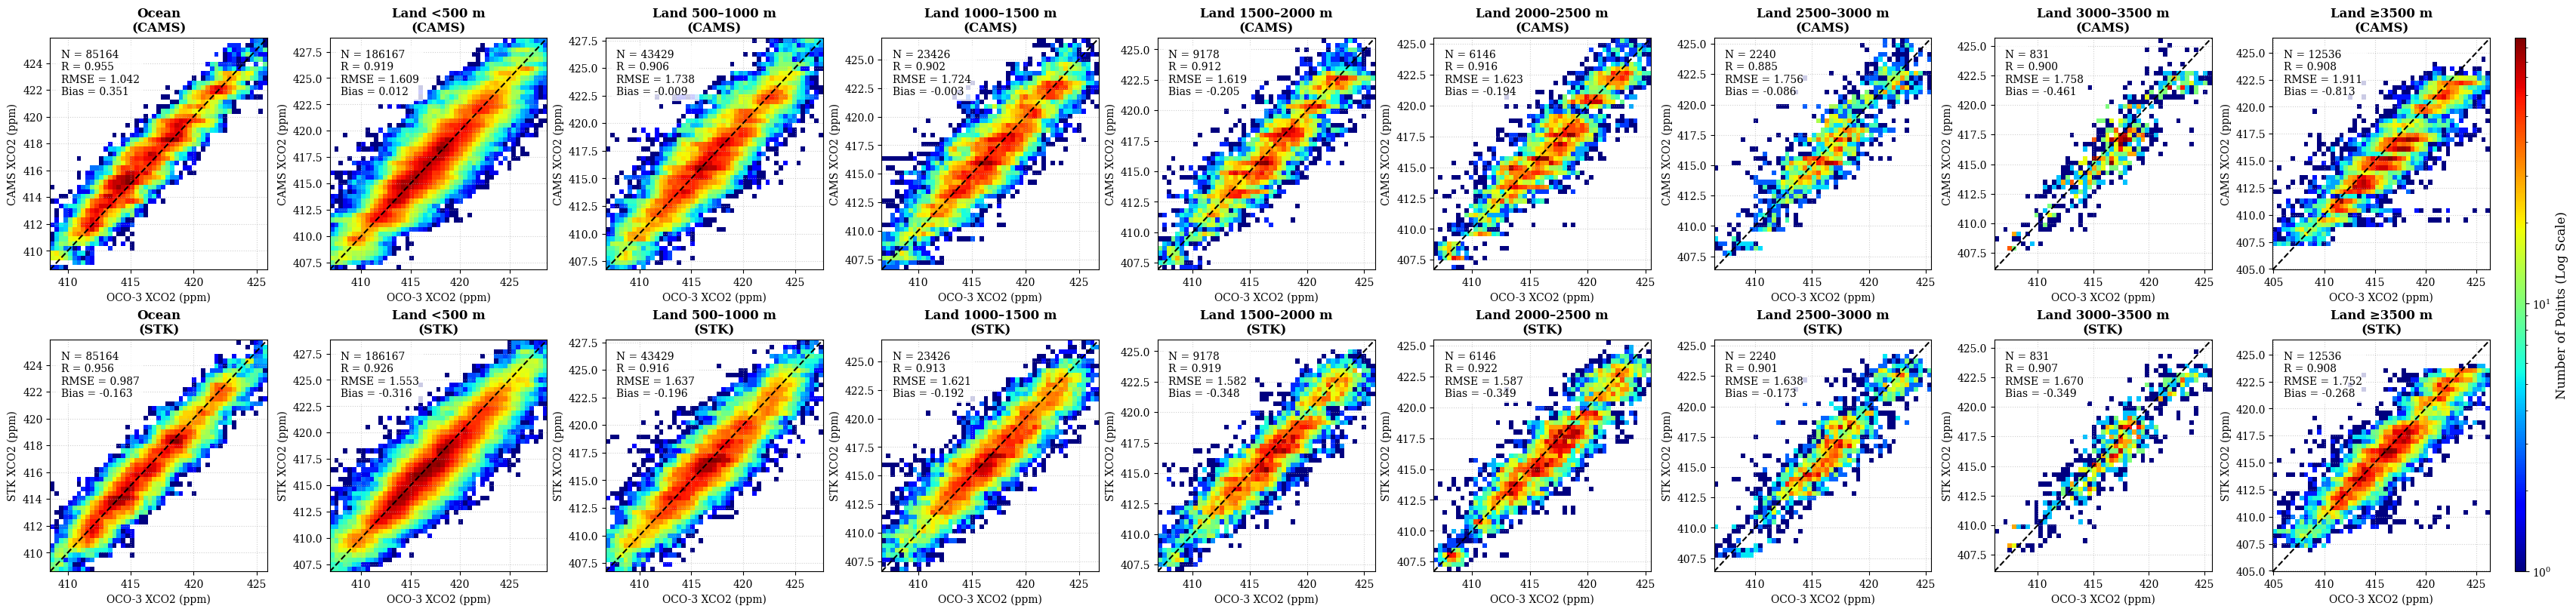

正在生成误差分布直方图...


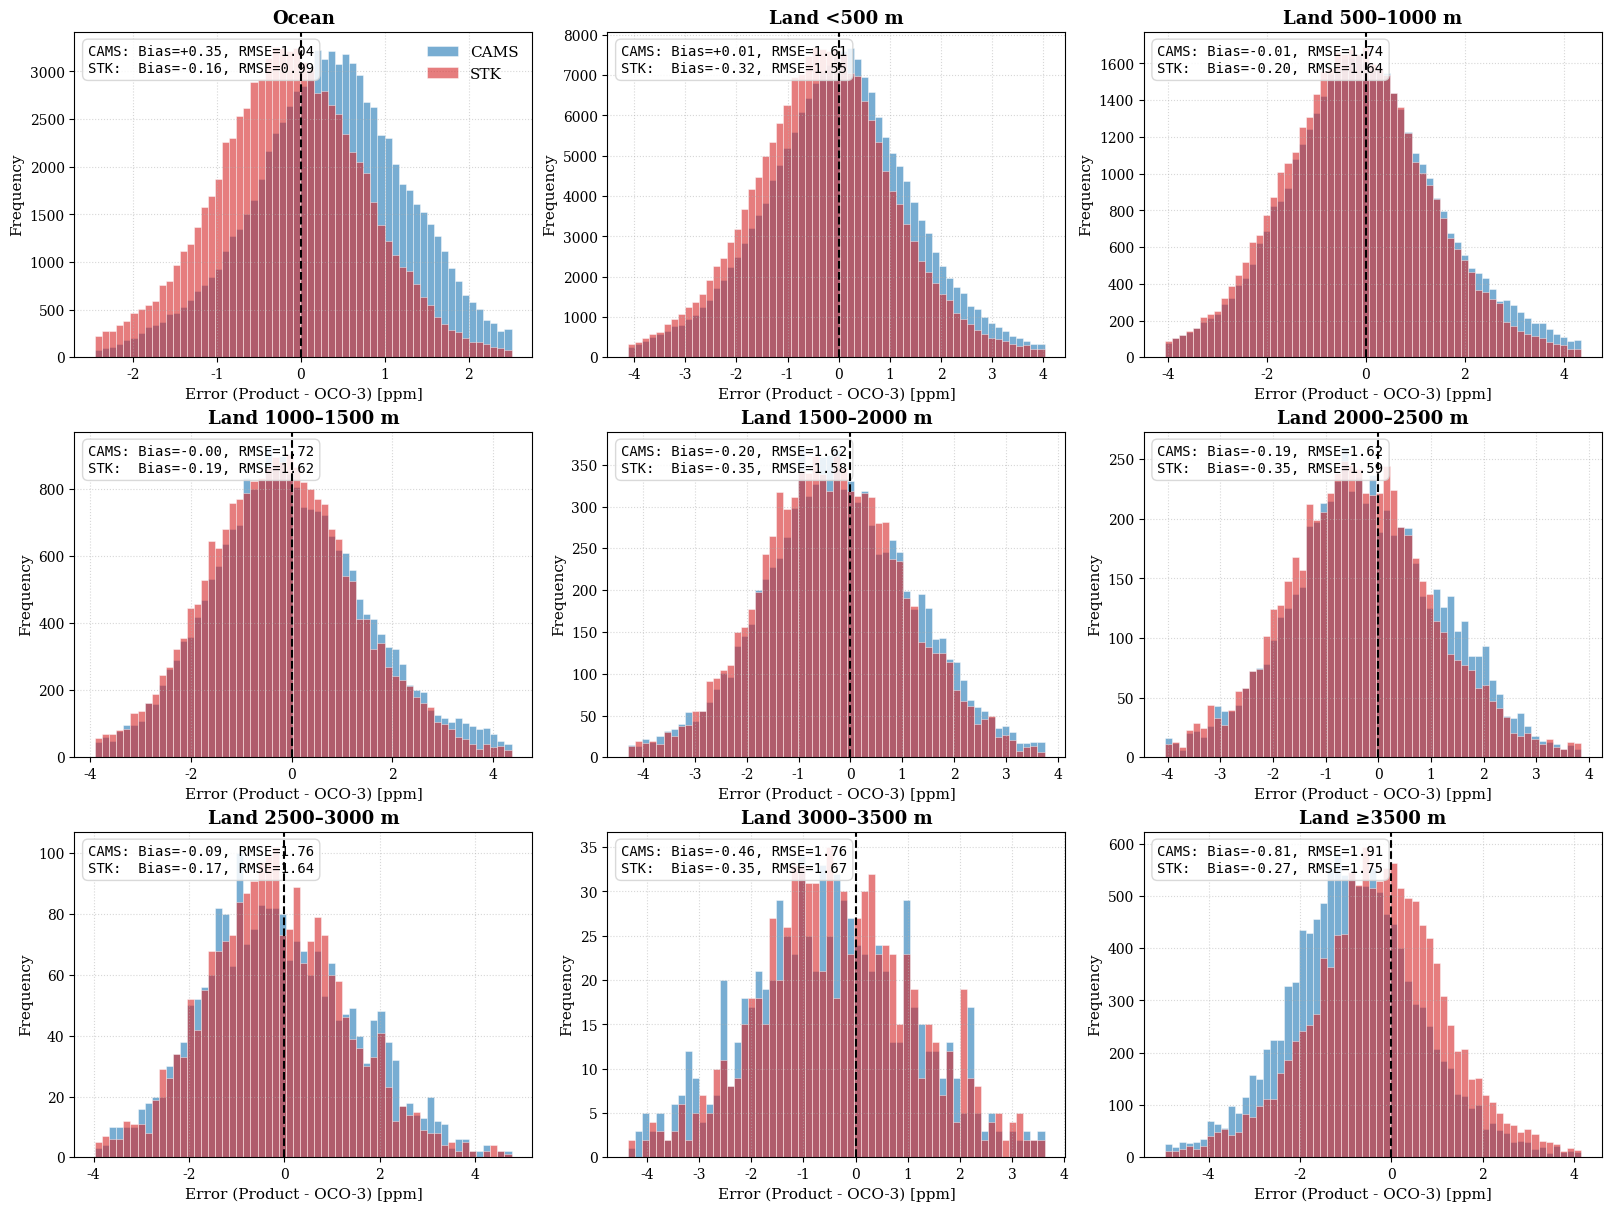

正在生成误差箱线图...


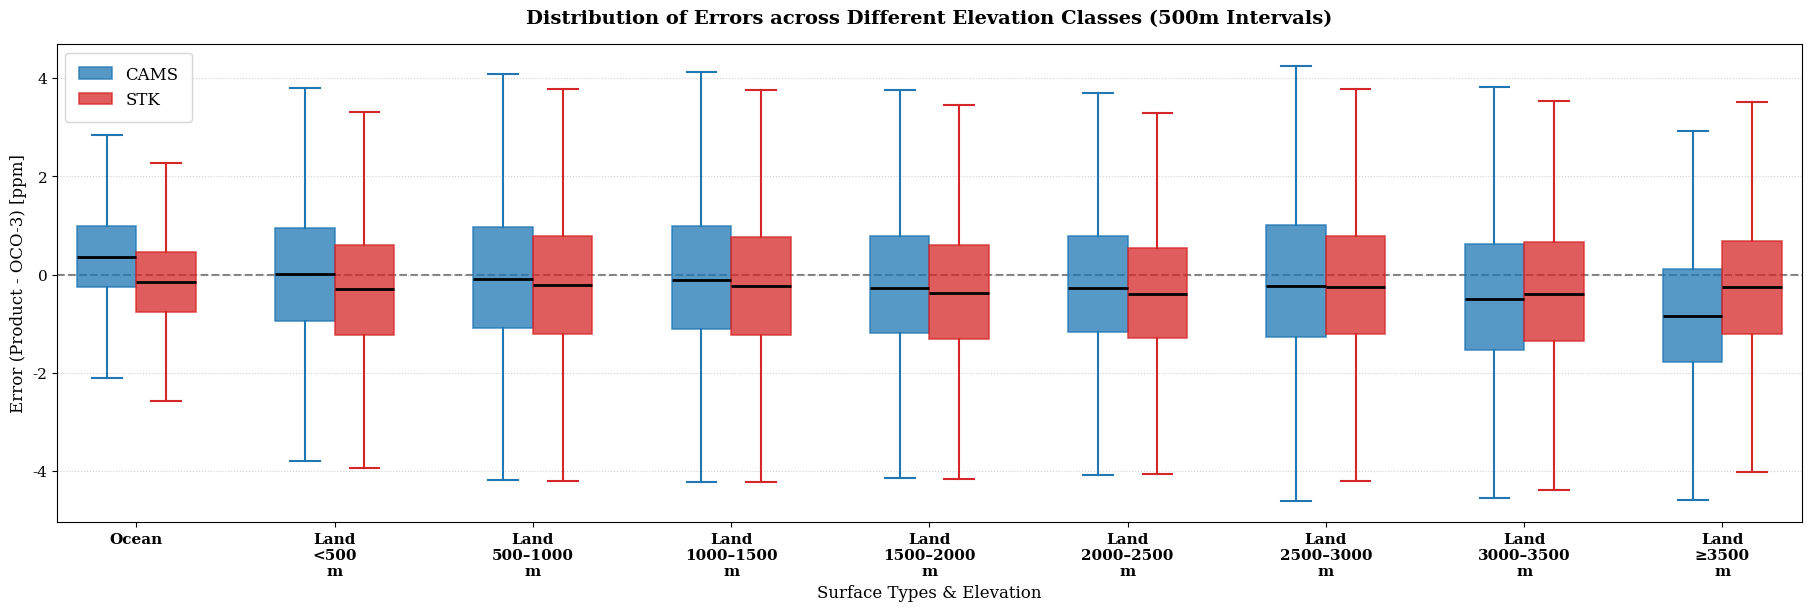

所有图像渲染和保存完成！


In [18]:
import ee
import geemap
import numpy as np
import pandas as pd
import xarray as xr
import rioxarray
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import pearsonr
from pathlib import Path

# ============================================================
# 0. 路径配置 (请替换为你实际的文件路径)
# ============================================================
# PROJECT_DIR = Path("你的项目根目录")
# oco3_nc = PROJECT_DIR / "data/Satellite/step03_Keeling_curve/oco3_xco2_month_201908_202512.nc"
# stk_nc = ...
# cams_nc = ...

# ============================================================
# 1. Read and preprocess
# ============================================================
def read_monthly(path):
    ds = xr.open_dataset(path)
    time = pd.to_datetime(ds.time.values).to_period("M").to_timestamp()
    ds = ds.assign_coords(time=time).drop_duplicates("time").sortby("time")
    lat_slice = slice(-10, 32) if ds.lat[0] < ds.lat[-1] else slice(32, -10)
    return ds["xco2"].sel(
        time=slice("2019-08-01", "2024-12-31"),
        lon=slice(92, 125),
        lat=lat_slice
    )

print("正在读取 NetCDF 数据...")
oco3 = read_monthly(oco3_nc)
stk  = read_monthly(stk_nc)
cams = read_monthly(cams_nc)

common_time = np.intersect1d(oco3.time.values, stk.time.values)
common_time = np.intersect1d(common_time, cams.time.values)

oco3 = oco3.sel(time=common_time)
stk  = stk.sel(time=common_time).interp(lat=oco3.lat, lon=oco3.lon, method="nearest")
cams = cams.sel(time=common_time).interp(lat=oco3.lat, lon=oco3.lon, method="nearest")

valid = np.isfinite(oco3) & np.isfinite(stk) & np.isfinite(cams)

err_stk  = (stk - oco3).where(valid)
err_cams = (cams - oco3).where(valid)

# ============================================================
# 2. GEE Download DEM & Land Mask
# ============================================================
print("\n正在初始化 Google Earth Engine...")
# ee.Authenticate() # 若尚未授权，请取消注释本行进行登录验证
ee.Initialize(project='ee-hongxu')

lon_min, lon_max = 92.0, 125.0
lat_min, lat_max = -10.0, 32.0
roi = ee.Geometry.BBox(lon_min, lat_min, lon_max, lat_max)

srtm = ee.Image('USGS/SRTMGL1_003')
dem_img = srtm.unmask(0)
land_img = srtm.mask()

gee_img = dem_img.addBands(land_img.rename('land_mask'))

dx_deg = 0.1
scale_m = int(dx_deg * 111320)

tif_path = 'gee_dem_land_01deg.tif'
print(f"正在从 GEE 下载高程和掩码 (范围 92-125E, 10S-32N, 分辨率: 0.1度, ~{scale_m}米)...")
geemap.ee_export_image(
    gee_img,
    filename=tif_path,
    scale=scale_m,
    region=roi,
    file_per_band=False
)

ds_gee = rioxarray.open_rasterio(tif_path)
ds_gee_regridded = ds_gee.interp(x=oco3.lon, y=oco3.lat, method='nearest')

dem = ds_gee_regridded.sel(band=1).values
land = ds_gee_regridded.sel(band=2).values.astype(bool)

# ============================================================
# 3. Classification & Statistics (500m 细化间隔)
# ============================================================
classes = {
    "Ocean": ~land,
    "Land <500 m": land & (dem < 500),
    "Land 500–1000 m": land & (dem >= 500) & (dem < 1000),
    "Land 1000–1500 m": land & (dem >= 1000) & (dem < 1500),
    "Land 1500–2000 m": land & (dem >= 1500) & (dem < 2000),
    "Land 2000–2500 m": land & (dem >= 2000) & (dem < 2500),
    "Land 2500–3000 m": land & (dem >= 2500) & (dem < 3000),
    "Land 3000–3500 m": land & (dem >= 3000) & (dem < 3500),
    "Land ≥3500 m": land & (dem >= 3500)
}

rows = []
print("\n正在计算各个高程区间的误差统计量...")
for name, mask in classes.items():
    m = xr.DataArray(
        mask,
        coords={"lat": oco3.lat, "lon": oco3.lon},
        dims=("lat", "lon")
    )

    ec = err_cams.where(m).values.ravel()
    es = err_stk.where(m).values.ravel()

    ok = np.isfinite(ec) & np.isfinite(es)
    ec, es = ec[ok], es[ok]

    if len(es) == 0:
        rows.append([name, 0, np.nan, np.nan, np.nan, np.nan, np.nan])
        continue

    cr = np.sqrt(np.mean(ec**2))
    sr = np.sqrt(np.mean(es**2))

    rows.append([
        name, len(es),
        cr, sr,
        (cr - sr) / cr * 100,
        np.mean(ec), np.mean(es)
    ])

df_elev = pd.DataFrame(rows, columns=[
    "Class", "N",
    "CAMS_RMSE", "STK_RMSE",
    "RMSE_reduction_%",
    "CAMS_Bias", "STK_Bias"
])

print("\n================ 统计结果 ================")
print(df_elev.round(3).to_string(index=False))
print("==========================================\n")

# ============================================================
# 4. Scatter Density Plots by Elevation Class
# ============================================================
print("正在生成散点密度图...")
# 根据9个分类调整画板，2行 9列
fig_sd, axes_sd = plt.subplots(nrows=2, ncols=len(classes), figsize=(34, 8), constrained_layout=True)
cmap_sd = plt.cm.jet

for i, (name, mask) in enumerate(classes.items()):
    m = xr.DataArray(mask, coords={"lat": oco3.lat, "lon": oco3.lon}, dims=("lat", "lon"))

    o_vals = oco3.where(m).values.ravel()
    c_vals = cams.where(m).values.ravel()
    s_vals = stk.where(m).values.ravel()

    valid_idx = np.isfinite(o_vals) & np.isfinite(c_vals) & np.isfinite(s_vals)
    o, c, s = o_vals[valid_idx], c_vals[valid_idx], s_vals[valid_idx]

    ax_c, ax_s = axes_sd[0, i], axes_sd[1, i]

    if len(o) < 10:
        ax_c.set_title(f"{name}\nNo Data"); ax_c.axis('off')
        ax_s.axis('off')
        continue

    vmin = np.percentile(np.concatenate([o, c, s]), 0.1)
    vmax = np.percentile(np.concatenate([o, c, s]), 99.9)
    bins = np.linspace(vmin, vmax, 50)

    # CAMS
    h_c = ax_c.hist2d(o, c, bins=[bins, bins], cmap=cmap_sd, cmin=1, norm=mcolors.LogNorm())
    c_rmse, c_bias = np.sqrt(np.mean((c - o)**2)), np.mean(c - o)
    c_r, _ = pearsonr(o, c)
    ax_c.plot([vmin, vmax], [vmin, vmax], 'k--', lw=1.5, zorder=5)
    ax_c.text(0.05, 0.95, f"N = {len(o)}\nR = {c_r:.3f}\nRMSE = {c_rmse:.3f}\nBias = {c_bias:.3f}",
              transform=ax_c.transAxes, va='top', ha='left', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'), fontsize=10)
    ax_c.set_title(f"{name}\n(CAMS)", fontsize=12, fontweight='bold')
    ax_c.set_xlabel("OCO-3 XCO2 (ppm)")
    ax_c.set_ylabel("CAMS XCO2 (ppm)")
    ax_c.grid(True, linestyle=':', alpha=0.6)

    # STK
    h_s = ax_s.hist2d(o, s, bins=[bins, bins], cmap=cmap_sd, cmin=1, norm=mcolors.LogNorm())
    s_rmse, s_bias = np.sqrt(np.mean((s - o)**2)), np.mean(s - o)
    s_r, _ = pearsonr(o, s)
    ax_s.plot([vmin, vmax], [vmin, vmax], 'k--', lw=1.5, zorder=5)
    ax_s.text(0.05, 0.95, f"N = {len(o)}\nR = {s_r:.3f}\nRMSE = {s_rmse:.3f}\nBias = {s_bias:.3f}",
              transform=ax_s.transAxes, va='top', ha='left', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'), fontsize=10)
    ax_s.set_title(f"{name}\n(STK)", fontsize=12, fontweight='bold')
    ax_s.set_xlabel("OCO-3 XCO2 (ppm)")
    ax_s.set_ylabel("STK XCO2 (ppm)")
    ax_s.grid(True, linestyle=':', alpha=0.6)

cbar = fig_sd.colorbar(h_s[3], ax=axes_sd.ravel().tolist(), aspect=50, pad=0.01)
cbar.set_label('Number of Points (Log Scale)', fontsize=12)
plt.savefig("Figure_Elevation_ScatterDensity.png", dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 5. Error Distribution Histograms by Elevation Class
# ============================================================
print("正在生成误差分布直方图...")
# 9个分类调整为 3行 x 3列
fig_hist, axes_hist = plt.subplots(nrows=3, ncols=3, figsize=(16, 12), constrained_layout=True)
axes_hist = axes_hist.flatten()

for i, (name, mask) in enumerate(classes.items()):
    ax = axes_hist[i]
    m = xr.DataArray(mask, coords={"lat": oco3.lat, "lon": oco3.lon}, dims=("lat", "lon"))
    ec = err_cams.where(m).values.ravel()
    es = err_stk.where(m).values.ravel()
    valid_idx = np.isfinite(ec) & np.isfinite(es)
    ec, es = ec[valid_idx], es[valid_idx]

    if len(ec) < 10:
        ax.set_title(f"{name} (No Data)"); ax.axis('off')
        continue

    vmin, vmax = np.percentile(np.concatenate([ec, es]), 1), np.percentile(np.concatenate([ec, es]), 99)
    vmin, vmax = min(vmin, -1), max(vmax, 1)
    bins = np.linspace(vmin, vmax, 60)

    ax.hist(ec, bins=bins, alpha=0.6, label='CAMS', color='#1f77b4', edgecolor='white', linewidth=0.5)
    ax.hist(es, bins=bins, alpha=0.6, label='STK', color='#d62728', edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='black', linestyle='--', lw=1.5, zorder=5)

    c_rmse, s_rmse = np.sqrt(np.mean(ec**2)), np.sqrt(np.mean(es**2))
    c_bias, s_bias = np.mean(ec), np.mean(es)

    stat_text = f"CAMS: Bias={c_bias:+.2f}, RMSE={c_rmse:.2f}\nSTK:  Bias={s_bias:+.2f}, RMSE={s_rmse:.2f}"
    ax.text(0.03, 0.96, stat_text, transform=ax.transAxes, va='top', ha='left',
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray', boxstyle='round,pad=0.4'), fontsize=10, family='monospace')

    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel("Error (Product - OCO-3) [ppm]", fontsize=11)
    ax.set_ylabel("Frequency", fontsize=11)
    ax.grid(True, linestyle=':', alpha=0.5)

    if i == 0:
        ax.legend(loc='upper right', frameon=False, fontsize=11)

plt.savefig("Figure_Elevation_ErrorHistograms.png", dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 6. Grouped Box Plots for Errors by Elevation Class
# ============================================================
print("正在生成误差箱线图...")
cams_data, stk_data, x_labels = [], [], []

for name, mask in classes.items():
    m = xr.DataArray(mask, coords={"lat": oco3.lat, "lon": oco3.lon}, dims=("lat", "lon"))
    ec = err_cams.where(m).values.ravel()
    es = err_stk.where(m).values.ravel()
    valid_idx = np.isfinite(ec) & np.isfinite(es)

    cams_data.append(ec[valid_idx])
    stk_data.append(es[valid_idx])
    x_labels.append(name.replace(" m", "\nm").replace(" ", "\n"))

# 拓宽画板以容纳 9 个分类
fig_box, ax_box = plt.subplots(figsize=(18, 6), constrained_layout=True)

x_positions = np.arange(len(classes)) * 2.0
box_width = 0.6

bp_cams = ax_box.boxplot(cams_data, positions=x_positions - box_width/2, widths=box_width, patch_artist=True, showfliers=False,
                         boxprops=dict(facecolor='#1f77b4', color='#1f77b4', alpha=0.75, linewidth=1.2),
                         capprops=dict(color='#1f77b4', linewidth=1.5), whiskerprops=dict(color='#1f77b4', linewidth=1.5), medianprops=dict(color='black', linewidth=2))

bp_stk = ax_box.boxplot(stk_data, positions=x_positions + box_width/2, widths=box_width, patch_artist=True, showfliers=False,
                        boxprops=dict(facecolor='#d62728', color='#d62728', alpha=0.75, linewidth=1.2),
                        capprops=dict(color='#d62728', linewidth=1.5), whiskerprops=dict(color='#d62728', linewidth=1.5), medianprops=dict(color='black', linewidth=2))

ax_box.axhline(0, color='gray', linestyle='--', linewidth=1.5, zorder=0)
ax_box.set_xticks(x_positions)
ax_box.set_xticklabels(x_labels, fontsize=11, fontweight='bold')
ax_box.set_xlabel("Surface Types & Elevation", fontsize=12)
ax_box.set_ylabel("Error (Product - OCO-3) [ppm]", fontsize=12)
ax_box.tick_params(axis='y', labelsize=11)
ax_box.legend([bp_cams["boxes"][0], bp_stk["boxes"][0]], ['CAMS', 'STK'], loc='upper left', frameon=True, fontsize=12, borderpad=0.8)
ax_box.grid(axis='y', linestyle=':', alpha=0.6)
ax_box.set_title("Distribution of Errors across Different Elevation Classes (500m Intervals)", fontsize=14, fontweight='bold', pad=15)

plt.savefig("Figure_Elevation_Boxplots.png", dpi=300, bbox_inches='tight')
plt.show()

print("所有图像渲染和保存完成！")


正在生成误差的空间分布图...


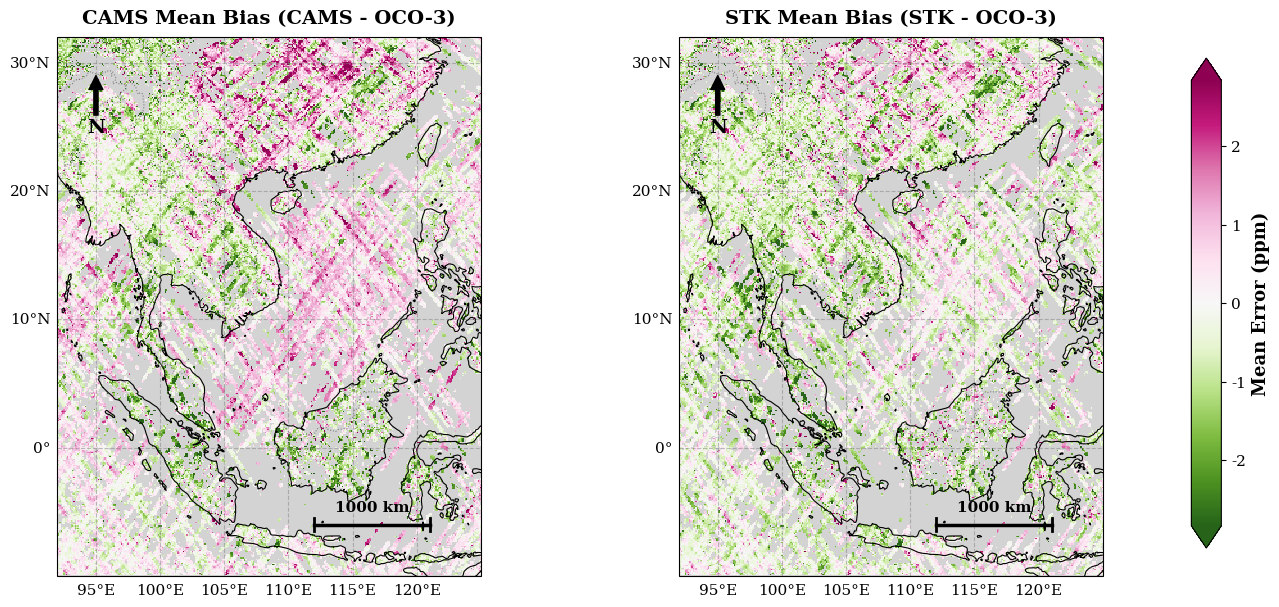

空间分布图绘制完成，图片已保存至: /content/drive/MyDrive/Southeast-Asia-XCO2-STK/output/Validation/Figure_Spatial_Error_Distribution_MapElements.png


In [30]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import copy

# ============================================================
# 7. Spatial Distribution of Mean Errors (带指北针和比例尺)
# ============================================================
print("\n正在生成误差的空间分布图...")

# 计算时间维度的平均误差 (忽略 NaN 值)
mean_err_cams = err_cams.mean(dim="time", skipna=True)
mean_err_stk  = err_stk.mean(dim="time", skipna=True)

# 计算色标范围避免极端值
all_errs = np.concatenate([mean_err_cams.values.ravel(), mean_err_stk.values.ravel()])
valid_errs = all_errs[np.isfinite(all_errs)]
vmax = np.percentile(np.abs(valid_errs), 98)
vmin = -vmax

# 设置带浅灰色背景的 Colormap
cmap = copy.copy(plt.get_cmap('PiYG_r'))
cmap.set_bad('lightgray')

fig = plt.figure(figsize=(15, 7))
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.PlateCarree())

plot_kwargs = {
    'cmap': cmap,
    'vmin': vmin,
    'vmax': vmax,
    'transform': ccrs.PlateCarree(),
    'shading': 'auto'
}

im1 = ax1.pcolormesh(oco3.lon, oco3.lat, mean_err_cams, **plot_kwargs)
ax1.set_title("CAMS Mean Bias (CAMS - OCO-3)", fontsize=14, fontweight='bold', pad=10)

im2 = ax2.pcolormesh(oco3.lon, oco3.lat, mean_err_stk, **plot_kwargs)
ax2.set_title("STK Mean Bias (STK - OCO-3)", fontsize=14, fontweight='bold', pad=10)

# 定义添加比例尺的辅助函数
def add_scalebar(ax, lon0, lat0, length_km):
    # 根据纬度计算近似的经度跨度 (1度经度约等于 111.32 * cos(纬度) km)
    lon_len = length_km / (111.32 * np.cos(np.radians(lat0)))
    # 画主线
    ax.plot([lon0, lon0 + lon_len], [lat0, lat0], color='k', linewidth=2.5, transform=ccrs.PlateCarree(), zorder=10)
    # 画两端的短竖线
    ax.plot([lon0, lon0], [lat0 - 0.5, lat0 + 0.5], color='k', linewidth=2, transform=ccrs.PlateCarree(), zorder=10)
    ax.plot([lon0 + lon_len, lon0 + lon_len], [lat0 - 0.5, lat0 + 0.5], color='k', linewidth=2, transform=ccrs.PlateCarree(), zorder=10)
    # 添加文字
    ax.text(lon0 + lon_len/2, lat0 + 0.8, f'{length_km} km', ha='center', va='bottom',
            fontsize=11, fontweight='bold', transform=ccrs.PlateCarree(), zorder=10)

for ax in [ax1, ax2]:
    ax.set_facecolor('lightgray')
    ax.set_extent([92, 125, -10, 32], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.8, edgecolor='gray')

    gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 11}
    gl.ylabel_style = {'size': 11}

    # === 添加指北针 (在左上角) ===
    # xy 是 N 字母的位置，xytext 是箭头起点
    ax.annotate('N', xy=(95, 29), xytext=(95, 25),
                arrowprops=dict(facecolor='black', width=3, headwidth=10, headlength=10),
                ha='center', va='center', fontsize=14, fontweight='bold',
                transform=ccrs.PlateCarree(), zorder=10)

    # === 添加比例尺 (在右下角，设定为 1000 km) ===
    add_scalebar(ax, lon0=112, lat0=-6, length_km=1000)

plt.subplots_adjust(right=0.9, wspace=0.15)

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im2, cax=cbar_ax, orientation='vertical', extend='both')
cbar.set_label('Mean Error (ppm)', fontsize=13, fontweight='bold')
cbar.ax.tick_params(labelsize=11)

# 保存图片
spatial_save_path = Validation_DIR / "Figure_Spatial_Error_Distribution_MapElements.png" # 适配了你的 Validation_DIR
plt.savefig(spatial_save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"空间分布图绘制完成，图片已保存至: {spatial_save_path}")